## Imports

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

## EDA

In [3]:
df = pd.read_csv('datasetml_2026.csv')
df.head()

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed


In [4]:
df.shape

(10000, 12)

In [5]:
df.dtypes

cgpa                        float64
backlogs                      int64
college_tier                 object
country                      object
university_ranking_band      object
internship_count              int64
aptitude_score              float64
communication_score         float64
specialization               object
industry                     object
internship_quality_score    float64
placement_status             object
dtype: object

In [6]:
df.describe()

,cgpa,backlogs,internship_count,aptitude_score,communication_score,internship_quality_score
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,6.998290,1.248100,1.49930,69.877531,65.158600,5.021436
std,0.802606,1.149904,1.20289,14.700532,14.740446,1.505975
min,4.000000,0.000000,0.00000,30.000000,30.000000,1.000000
25%,6.461928,0.000000,1.00000,59.880399,55.112244,4.012656
50%,6.997924,1.000000,1.00000,70.097368,65.006484,5.017335
75%,7.536865,2.000000,2.00000,80.213934,75.277248,6.031400
max,10.000000,6.000000,5.00000,100.000000,100.000000,10.000000


In [7]:
# cari yg null
df.isnull().sum()

cgpa                        0
backlogs                    0
college_tier                0
country                     0
university_ranking_band     0
internship_count            0
aptitude_score              0
communication_score         0
specialization              0
industry                    0
internship_quality_score    0
placement_status            0
dtype: int64

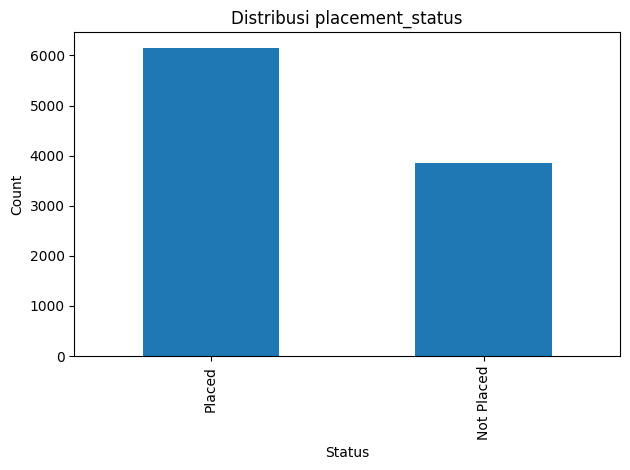

In [8]:
# Distribusi target
df['placement_status'].value_counts().plot(kind='bar')
plt.title('Distribusi placement_status')
plt.xlabel('Status')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

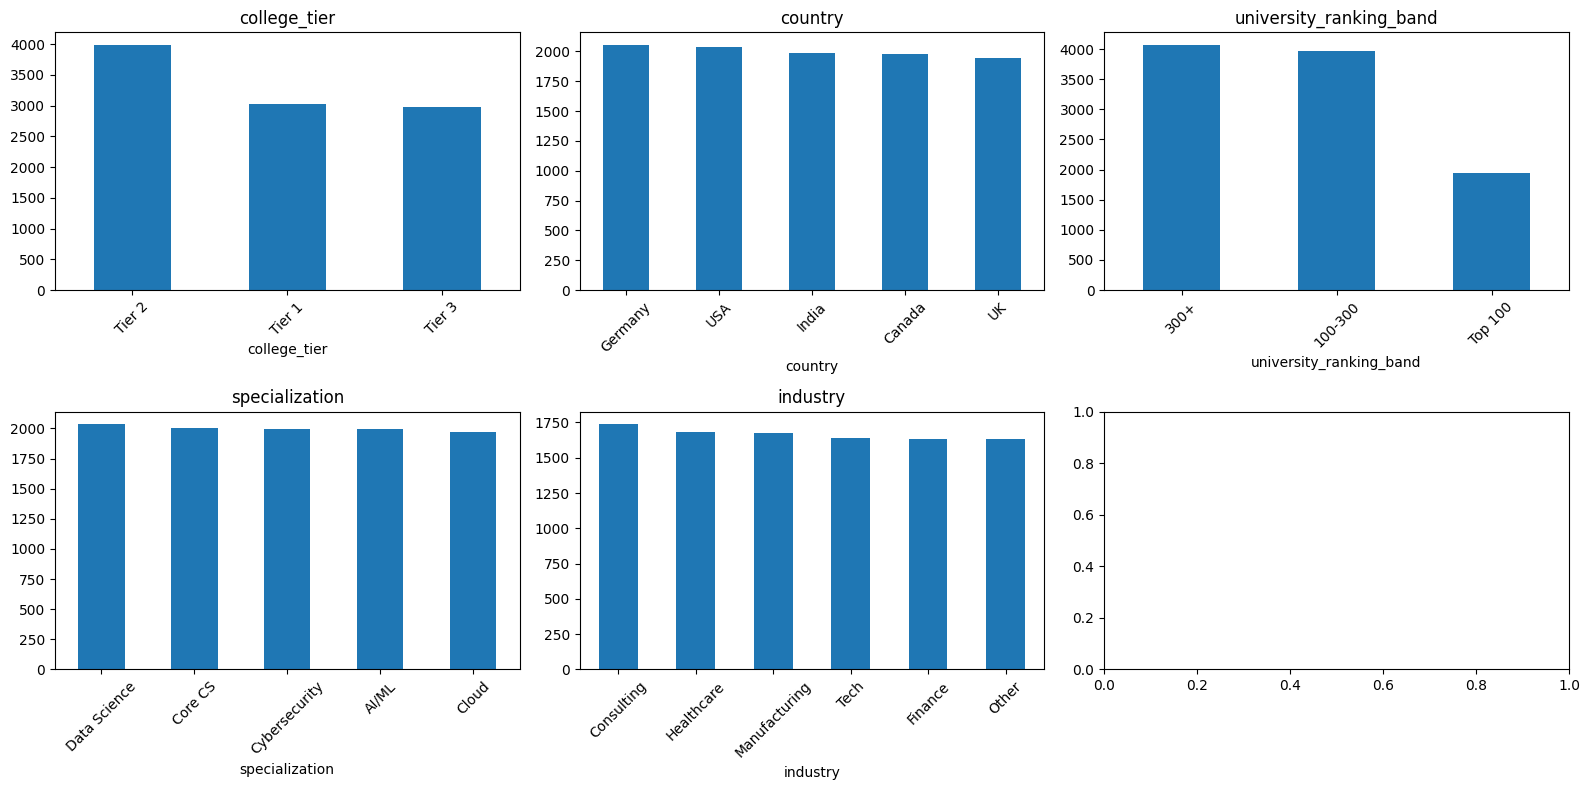

In [9]:
# Distribusi fitur kategorikal
cat_cols = ['college_tier', 'country', 'university_ranking_band', 'specialization', 'industry']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), cat_cols):
    df[col].value_counts().plot(kind='bar', ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

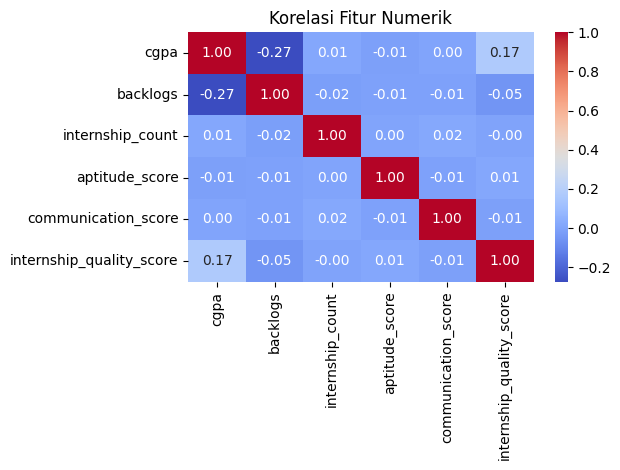

In [10]:
# Korelasi fitur numerik
num_cols = ['cgpa', 'backlogs', 'internship_count', 'aptitude_score',
            'communication_score', 'internship_quality_score']

import seaborn as sns
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Korelasi Fitur Numerik')
plt.tight_layout()
plt.show()

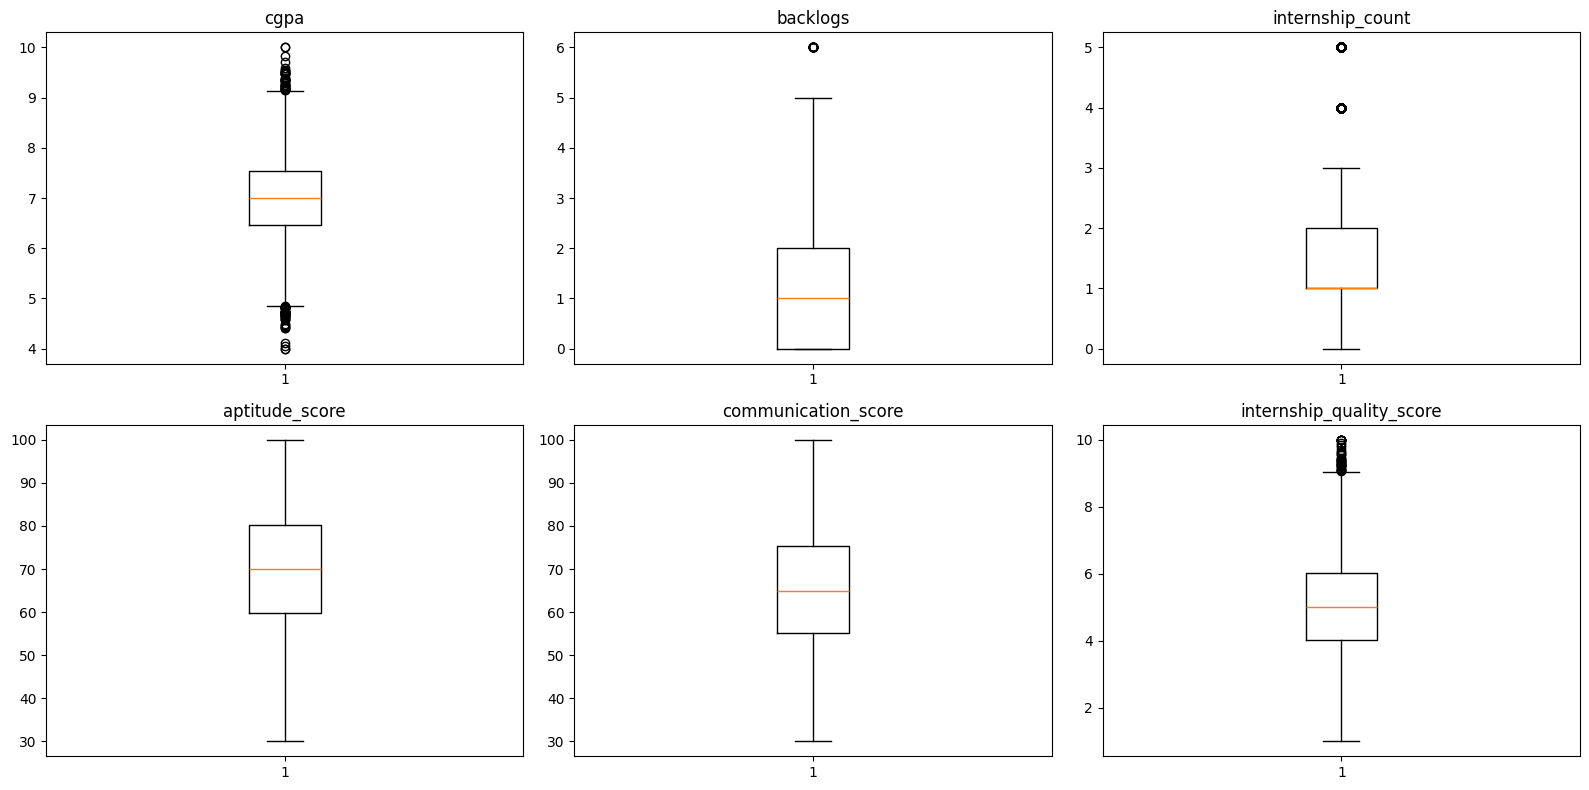

In [11]:
# Outlier
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), num_cols):
    ax.boxplot(df[col].dropna())
    ax.set_title(col)
plt.tight_layout()
plt.show()

## Preprocessing

In [12]:
# encode kolom kategorikal
cat_cols = ['college_tier', 'country', 'university_ranking_band',
            'specialization', 'industry']
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [13]:
# pisah fitur dan target
X = df.drop(columns=['placement_status']).values
y = le.fit_transform(df['placement_status'].astype(str)).reshape(-1, 1)

In [14]:
# normalisasi fitur numerik
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [15]:
# split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val   = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (7200, 11), Val: (800, 11), Test: (2000, 11)


## Model Testing

Random init, 100 epoch dengan 0.1% learning rate

Training Custom FFNN Model...
Epoch   1/100 [>....................] - loss: 0.6898 - acc: 0.6147 - val_loss: 0.6874 - val_acc: 0.6125
Epoch   2/100 [>....................] - loss: 0.6852 - acc: 0.6147 - val_loss: 0.6834 - val_acc: 0.6125
Epoch   3/100 [>....................] - loss: 0.6815 - acc: 0.6147 - val_loss: 0.6802 - val_acc: 0.6125
Epoch   4/100 [>....................] - loss: 0.6786 - acc: 0.6147 - val_loss: 0.6776 - val_acc: 0.6125
Epoch   5/100 [=>...................] - loss: 0.6762 - acc: 0.6147 - val_loss: 0.6756 - val_acc: 0.6125
Epoch   6/100 [=>...................] - loss: 0.6743 - acc: 0.6147 - val_loss: 0.6740 - val_acc: 0.6125
Epoch   7/100 [=>...................] - loss: 0.6728 - acc: 0.6147 - val_loss: 0.6727 - val_acc: 0.6125
Epoch   8/100 [=>...................] - loss: 0.6716 - acc: 0.6147 - val_loss: 0.6717 - val_acc: 0.6125
Epoch   9/100 [=>...................] - loss: 0.6706 - acc: 0.6147 - val_loss: 0.6708 - val_acc: 0.6125
Epoch  10/100 [==>................

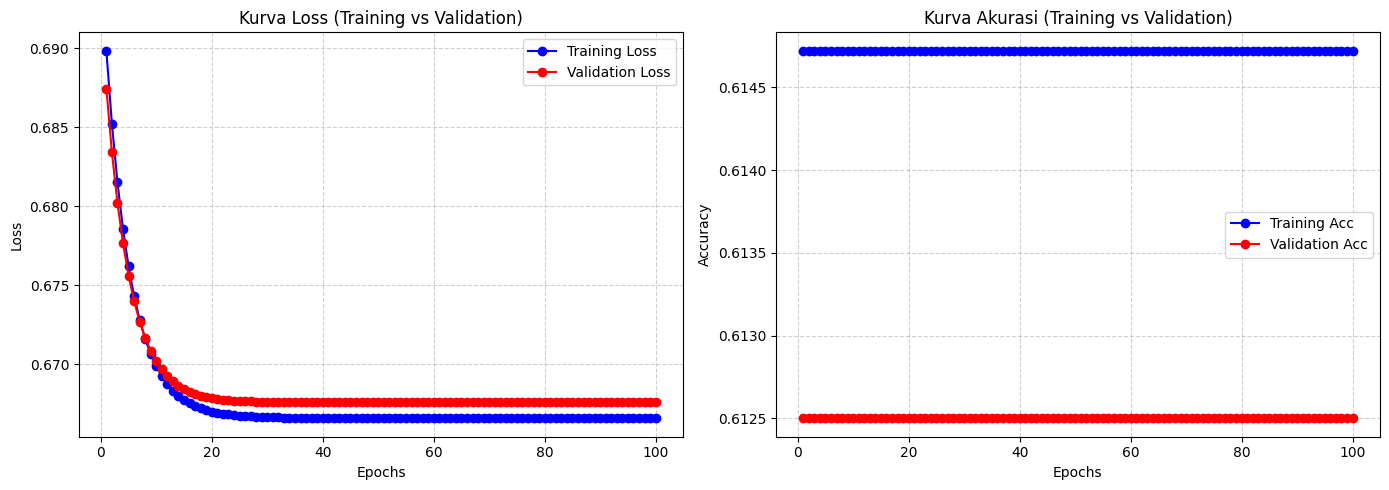


CUSTOM FFNN MODEL - CLASSIFICATION REPORT
--- Laporan Klasifikasi ---
Total Data : 2000
Akurasi    : 61.25%

CONFUSION MATRIX - CUSTOM FFNN
[[   0  775]
 [   0 1225]]


In [16]:
from ffnn.ffnn import FFNN
from ffnn import utils
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report as sklearn_classification_report

# Convert labels to one-hot encoding for FFNN
y_train_onehot = utils.create_one_hot(y_train.ravel(), num_classes=2)
y_test_onehot = utils.create_one_hot(y_test.ravel(), num_classes=2)

input_dim = X_train.shape[1]
num_classes = 2

# Create and train model with improved hyperparameters
model = FFNN(
    layer_sizes=[input_dim, 64, 32, num_classes], 
    activations=["relu", "relu", "softmax"],
    init_method="random_normal",
    learning_rate=0.001, 
    epochs=100, 
    batch_size=16, 
    l2_lambda=0.0001,
    verbose=1,
    variance=0.01,
    seed=42
)

print("Training Custom FFNN Model...")
# Train model
history = model.fit(
    X_train, y_train_onehot,
    X_val=X_test, y_val=y_test_onehot
)

# Plot training history
utils.plot_history(history)

# Prediksi data test
y_pred_probs = model.predict(X_test)
y_pred_labels = np.argmax(y_pred_probs, axis=1)

# Tampilkan Akurasi Akhir
print("\n" + "="*60)
print("CUSTOM FFNN MODEL - CLASSIFICATION REPORT")
print("="*60)
utils.classification_report(y_test.ravel(), y_pred_labels)

print("\n" + "="*60)
print("CONFUSION MATRIX - CUSTOM FFNN")
print("="*60)
print(confusion_matrix(y_test.ravel(), y_pred_labels))

Random init layers & activation, 100 iteration with 10% learning rate. Mari kita coba

ATTEMPT 2: Higher Learning Rate with Better Initialization

Training Model 2 with LR=0.1...
Epoch   1/100 [>....................] - loss: 0.6693 - acc: 0.6125 - val_loss: 0.6676 - val_acc: 0.6125
Epoch   2/100 [>....................] - loss: 0.6668 - acc: 0.6147 - val_loss: 0.6676 - val_acc: 0.6125
Epoch   3/100 [>....................] - loss: 0.6667 - acc: 0.6147 - val_loss: 0.6676 - val_acc: 0.6125
Epoch   4/100 [>....................] - loss: 0.6668 - acc: 0.6147 - val_loss: 0.6676 - val_acc: 0.6125
Epoch   5/100 [=>...................] - loss: 0.6667 - acc: 0.6147 - val_loss: 0.6677 - val_acc: 0.6125
Epoch   6/100 [=>...................] - loss: 0.6668 - acc: 0.6147 - val_loss: 0.6675 - val_acc: 0.6125
Epoch   7/100 [=>...................] - loss: 0.6667 - acc: 0.6147 - val_loss: 0.6675 - val_acc: 0.6125
Epoch   8/100 [=>...................] - loss: 0.6666 - acc: 0.6147 - val_loss: 0.6678 - val_acc: 0.6125
Epoch   9/100 [=>...................] - loss: 0.6664 - acc: 0.6147 - val_los

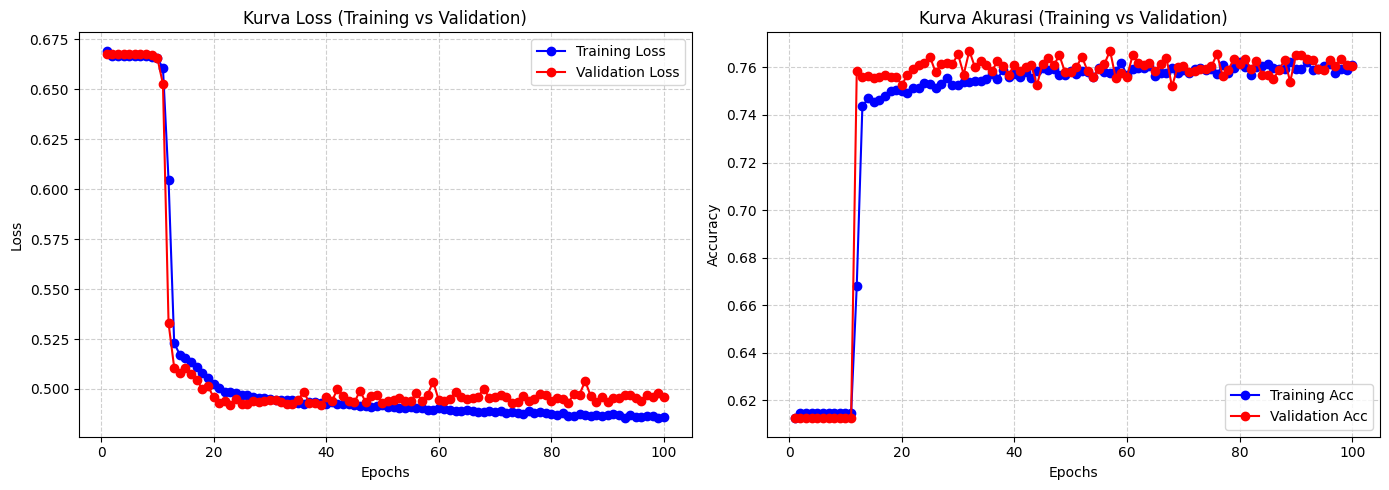


MODEL 2 - CLASSIFICATION REPORT
--- Laporan Klasifikasi ---
Total Data : 2000
Akurasi    : 76.05%

CONFUSION MATRIX - MODEL 2
[[ 472  303]
 [ 176 1049]]

MODEL 2 - DIAGNOSTIC
Initial train loss: 0.669341
Final train loss: 0.486116
Initial train accuracy: 0.612500
Final train accuracy: 0.760833
Test accuracy: 0.760500


In [17]:
print("="*60)
print("ATTEMPT 2: Higher Learning Rate with Better Initialization")
print("="*60)

# Re-import fresh
from ffnn.ffnn import FFNN
from ffnn import utils
from ffnn import losses

model2 = FFNN(
    layer_sizes=[input_dim, 32, 16, num_classes],
    activations=["relu", "relu", "softmax"],
    init_method="random_normal",
    learning_rate=0.1,  # Much higher learning rate
    epochs=100,
    batch_size=32,
    l2_lambda=0.0, 
    verbose=1,
    variance=0.1, 
    seed=42
)

print("\nTraining Model 2 with LR=0.1...")
history2 = model2.fit(
    X_train, y_train_onehot,
    X_val=X_test, y_val=y_test_onehot
)

utils.plot_history(history2)

# Predictions
y_pred_probs2 = model2.predict(X_test)
y_pred_labels2 = np.argmax(y_pred_probs2, axis=1)

print("\n" + "="*60)
print("MODEL 2 - CLASSIFICATION REPORT")
print("="*60)
utils.classification_report(y_test.ravel(), y_pred_labels2)

print("\n" + "="*60)
print("CONFUSION MATRIX - MODEL 2")
print("="*60)
print(confusion_matrix(y_test.ravel(), y_pred_labels2))

# Diagnostic
print("\n" + "="*60)
print("MODEL 2 - DIAGNOSTIC")
print("="*60)
print(f"Initial train loss: {history2['train_loss'][0]:.6f}")
print(f"Final train loss: {history2['train_loss'][-1]:.6f}")
print(f"Initial train accuracy: {history2['train_acc'][0]:.6f}")
print(f"Final train accuracy: {history2['train_acc'][-1]:.6f}")
print(f"Test accuracy: {np.mean(y_pred_labels2 == y_test.ravel()):.6f}")

### 1. Hyperparameter

#### Pengaruh Learning Rate

Eksperimen dengan 3 variasi learning rate menggunakan arsitektur dan hyperparameter yang sama.

In [18]:
from ffnn.ffnn import FFNN
from ffnn import utils
from sklearn.metrics import accuracy_score

# Fixed hyperparams
LAYER_SIZES = [X_train.shape[1], 64, 32, 2]
ACTIVATIONS = ["relu", "relu", "softmax"]
EPOCHS = 100
BATCH_SIZE = 32
SEED = 42

y_train_onehot = utils.create_one_hot(y_train.ravel(), num_classes=2)
y_val_onehot   = utils.create_one_hot(y_val.ravel(), num_classes=2)
y_test_onehot  = utils.create_one_hot(y_test.ravel(), num_classes=2)

learning_rates = [0.1, 0.01, 0.001]
histories = {}
results = {}

for lr in learning_rates:
    print(f"\n{'='*50}\nTraining dengan LR = {lr}\n{'='*50}")
    model = FFNN(
        layer_sizes=LAYER_SIZES,
        activations=ACTIVATIONS,
        init_method="he",
        learning_rate=lr,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        seed=SEED,
        verbose=1
    )
    history = model.fit(X_train, y_train_onehot, X_val=X_val, y_val=y_val_onehot)
    histories[lr] = history
    results[lr] = {
        "model": model,
        "accuracy": accuracy_score(y_test.ravel(), np.argmax(model.predict(X_test), axis=1))
    }


Training dengan LR = 0.1
Epoch   1/100 [>....................] - loss: 0.5625 - acc: 0.7201 - val_loss: 0.4880 - val_acc: 0.7600
Epoch   2/100 [>....................] - loss: 0.5223 - acc: 0.7462 - val_loss: 0.4798 - val_acc: 0.7638
Epoch   3/100 [>....................] - loss: 0.5130 - acc: 0.7493 - val_loss: 0.4792 - val_acc: 0.7700
Epoch   4/100 [>....................] - loss: 0.5086 - acc: 0.7515 - val_loss: 0.4744 - val_acc: 0.7600
Epoch   5/100 [=>...................] - loss: 0.5045 - acc: 0.7540 - val_loss: 0.4806 - val_acc: 0.7625
Epoch   6/100 [=>...................] - loss: 0.5033 - acc: 0.7521 - val_loss: 0.4744 - val_acc: 0.7712
Epoch   7/100 [=>...................] - loss: 0.4997 - acc: 0.7578 - val_loss: 0.4731 - val_acc: 0.7675
Epoch   8/100 [=>...................] - loss: 0.4981 - acc: 0.7576 - val_loss: 0.4735 - val_acc: 0.7700
Epoch   9/100 [=>...................] - loss: 0.4962 - acc: 0.7575 - val_loss: 0.4782 - val_acc: 0.7650
Epoch  10/100 [==>..................] 

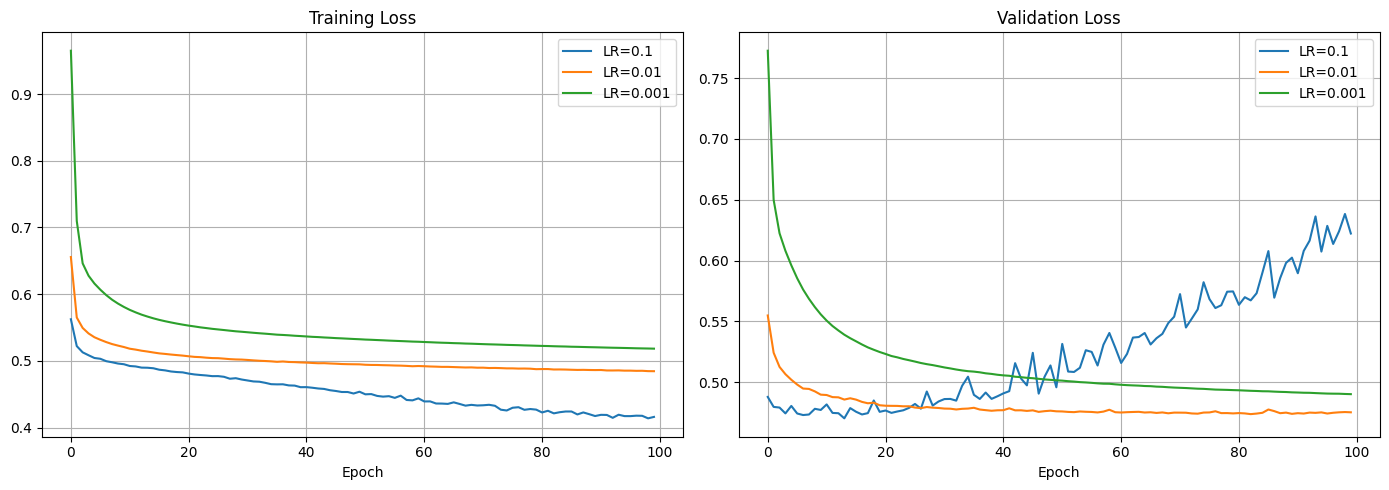

In [19]:
# Perbandingan traning & validation loss

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for lr in learning_rates:
    axes[0].plot(histories[lr]['train_loss'], label=f'LR={lr}')
    axes[1].plot(histories[lr]['val_loss'],   label=f'LR={lr}')

axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True)
axes[1].set_title('Validation Loss'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.show()

R=0.1 konvergen paling cepat dan mencapai training loss terendah (~0.41), namun validation loss-nya naik secara signifikan setelah epoch ~40 hingga mencapai ~0.64 mengindikasikan terjadinya **overfitting**. LR=0.01 menunjukkan konvergensi yang stabil dengan gap training dan validation loss yang kecil dan konsisten. LR=0.001 konvergen paling lambat dan training loss masih turun di epoch 100, mengindikasikan model **belum konvergen** sepenuhnya dalam 100 epoch.

In [20]:
# Perbandingan akurasi akhir

for lr in learning_rates:
    print(f"LR={lr:5} | Test Accuracy: {results[lr]['accuracy']:.4f}")

LR=  0.1 | Test Accuracy: 0.7210
LR= 0.01 | Test Accuracy: 0.7520
LR=0.001 | Test Accuracy: 0.7455


LR=0.01 menghasilkan akurasi tertinggi (75.20%). LR=0.1 terlalu besar sehingga overshoot saat update bobot, menghasilkan akurasi terendah. LR=0.001 performanya cukup baik namun belum optimal karena dengan 100 epoch kemungkinan belum sepenuhnya konvergen.


LR = 0.1

               DISTRIBUSI BOBOT (WEIGHTS) & BIAS                 
Layer   | Param | Min        | Max        | Mean       | Std       
-----------------------------------------------------------------
1       | W     | -1.2980    | 1.5287     | -0.0017    | 0.4436    
        | b     | -0.3712    | 0.2831     | -0.0793    | 0.1360    
-----------------------------------------------------------------
2       | W     | -0.8860    | 0.6890     | -0.0048    | 0.2303    
        | b     | -0.3244    | 0.1877     | -0.0179    | 0.1064    
-----------------------------------------------------------------
3       | W     | -0.9927    | 0.7939     | -0.0478    | 0.5146    
        | b     | -0.2323    | 0.2323     | -0.0000    | 0.2323    
-----------------------------------------------------------------


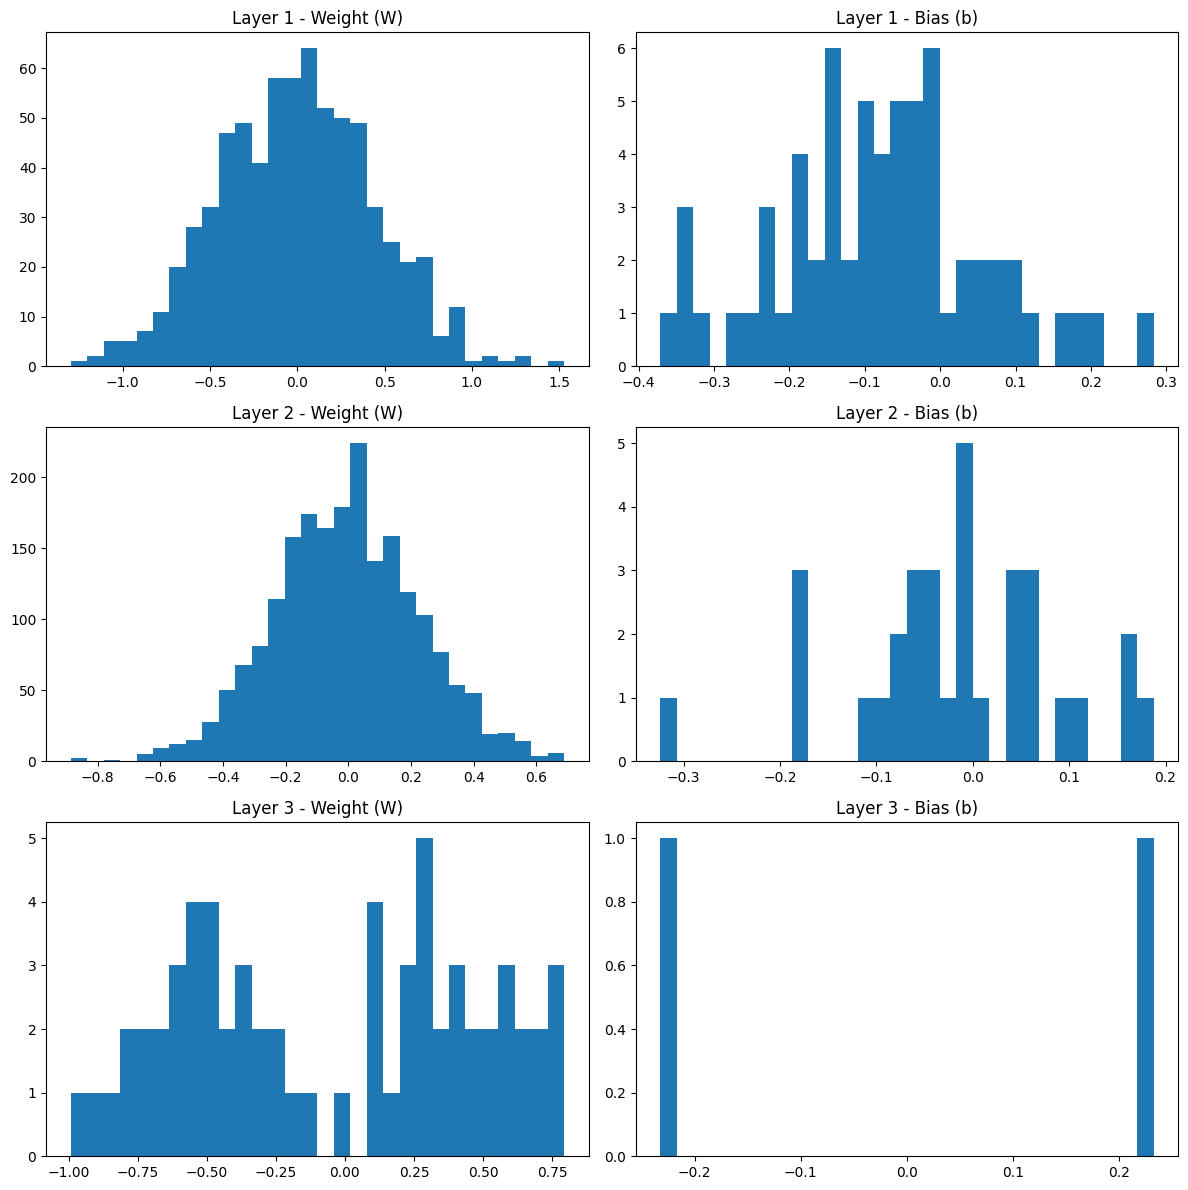


               DISTRIBUSI GRADIEN (ERROR SIGNAL)                 
Layer   | Param | Min        | Max        | Mean       | Std       
-----------------------------------------------------------------
1       | dW    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
        | db    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
-----------------------------------------------------------------
2       | dW    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
        | db    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
-----------------------------------------------------------------
3       | dW    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
        | db    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
-----------------------------------------------------------------


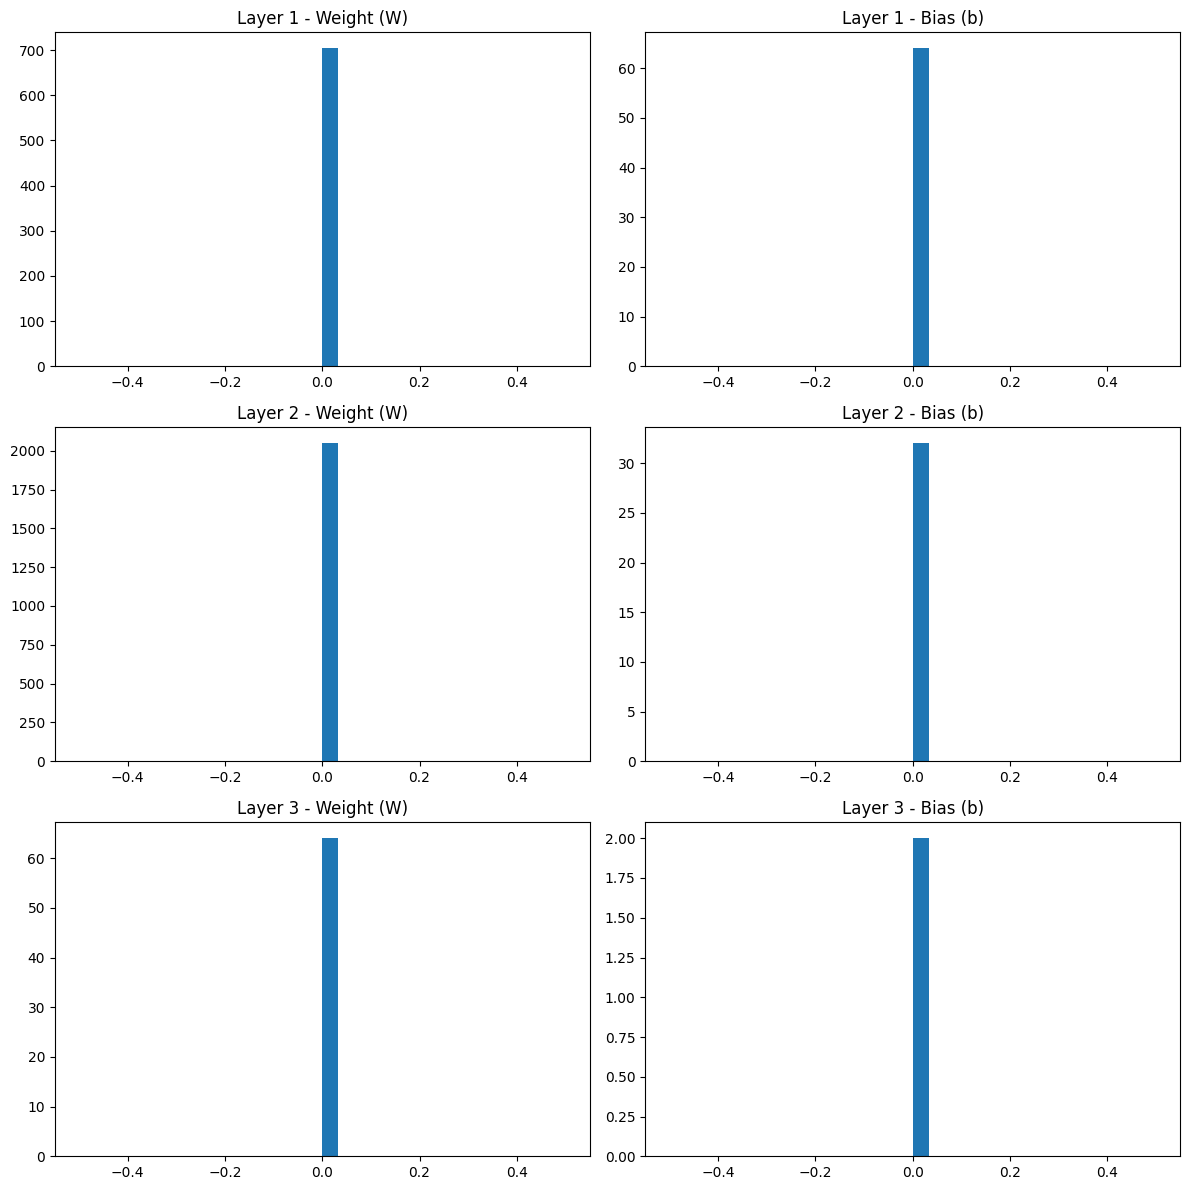


LR = 0.01

               DISTRIBUSI BOBOT (WEIGHTS) & BIAS                 
Layer   | Param | Min        | Max        | Mean       | Std       
-----------------------------------------------------------------
1       | W     | -1.3890    | 1.6438     | -0.0049    | 0.4195    
        | b     | -0.0615    | 0.1031     | 0.0071     | 0.0290    
-----------------------------------------------------------------
2       | W     | -0.5752    | 0.6328     | 0.0058     | 0.1749    
        | b     | -0.0395    | 0.0461     | -0.0032    | 0.0159    
-----------------------------------------------------------------
3       | W     | -0.4518    | 0.4629     | -0.0478    | 0.2186    
        | b     | -0.0442    | 0.0442     | -0.0000    | 0.0442    
-----------------------------------------------------------------


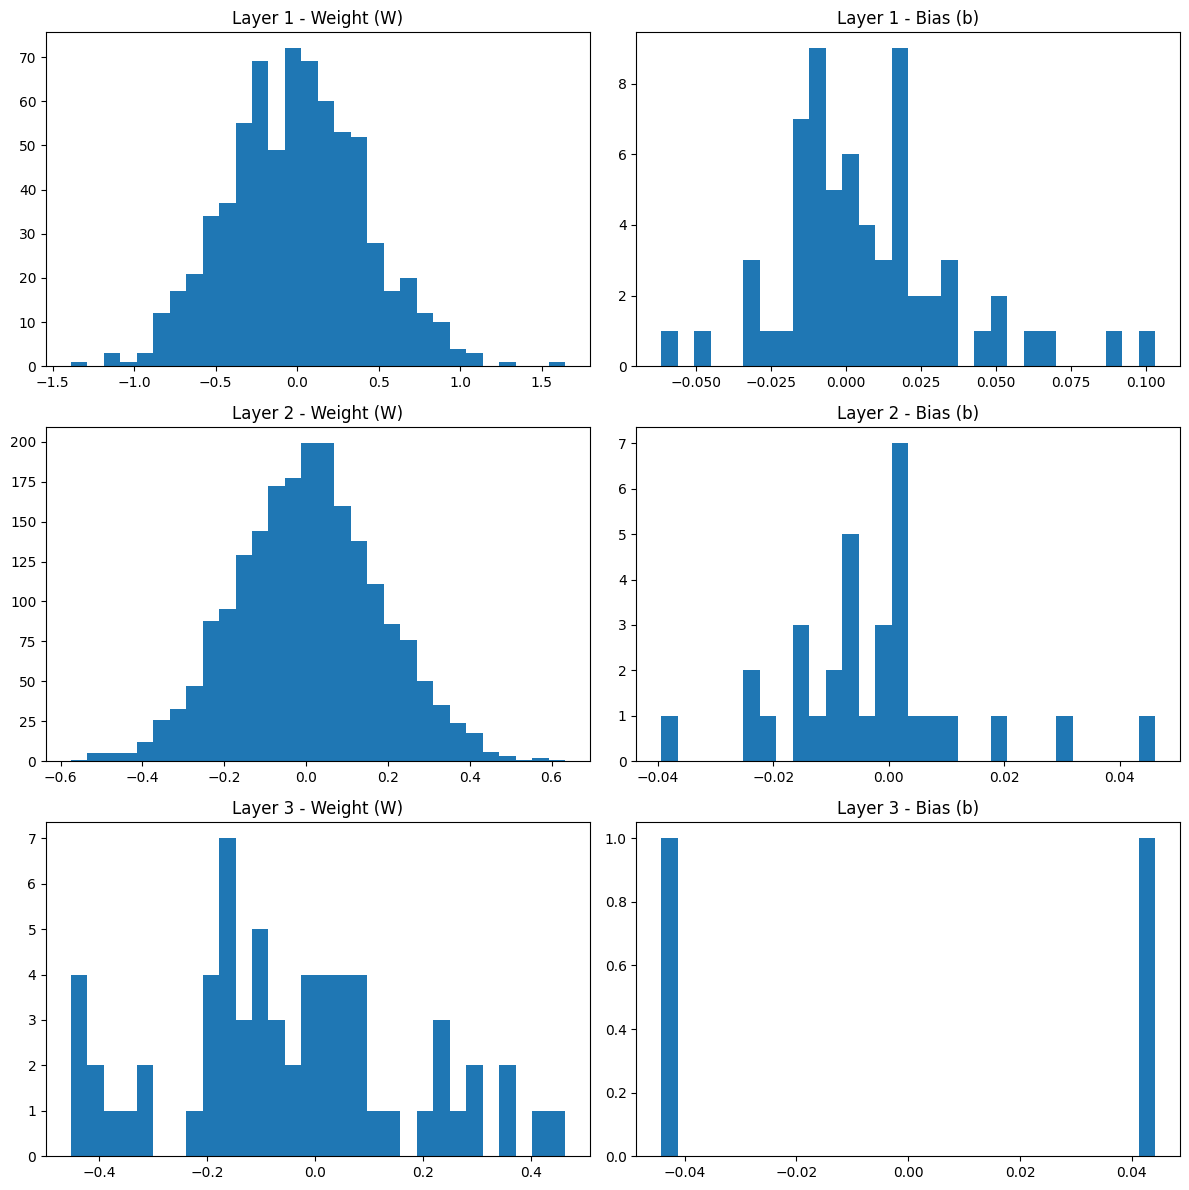


               DISTRIBUSI GRADIEN (ERROR SIGNAL)                 
Layer   | Param | Min        | Max        | Mean       | Std       
-----------------------------------------------------------------
1       | dW    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
        | db    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
-----------------------------------------------------------------
2       | dW    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
        | db    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
-----------------------------------------------------------------
3       | dW    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
        | db    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
-----------------------------------------------------------------


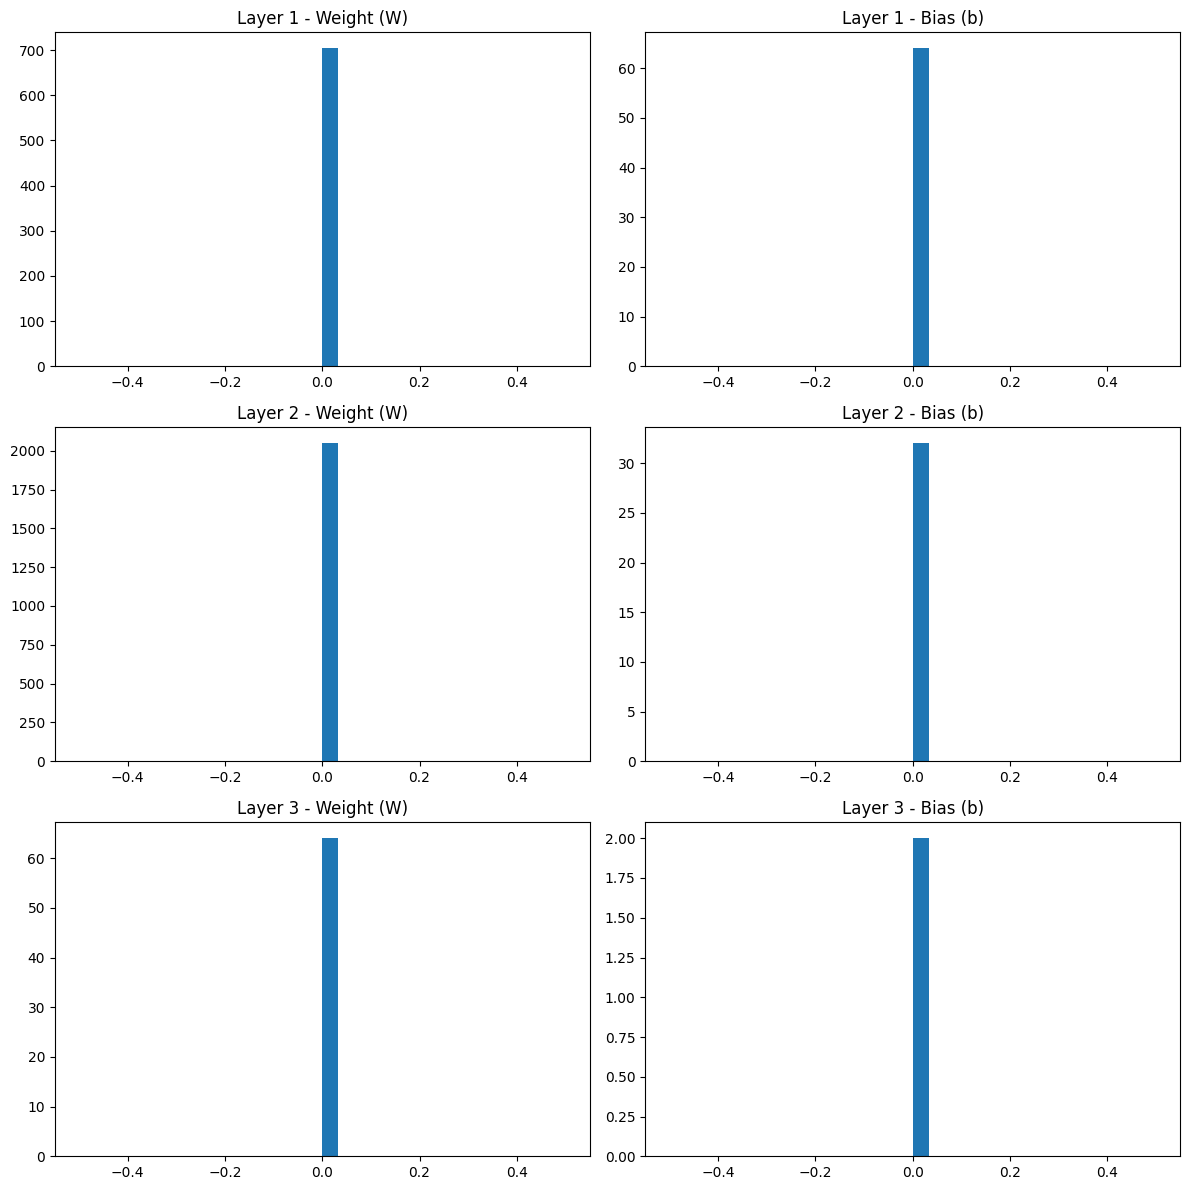


LR = 0.001

               DISTRIBUSI BOBOT (WEIGHTS) & BIAS                 
Layer   | Param | Min        | Max        | Mean       | Std       
-----------------------------------------------------------------
1       | W     | -1.3731    | 1.6344     | -0.0045    | 0.4193    
        | b     | -0.0159    | 0.0215     | 0.0017     | 0.0086    
-----------------------------------------------------------------
2       | W     | -0.5667    | 0.6435     | 0.0071     | 0.1745    
        | b     | -0.0291    | 0.0399     | -0.0000    | 0.0135    
-----------------------------------------------------------------
3       | W     | -0.4448    | 0.4638     | -0.0478    | 0.2102    
        | b     | -0.0353    | 0.0353     | -0.0000    | 0.0353    
-----------------------------------------------------------------


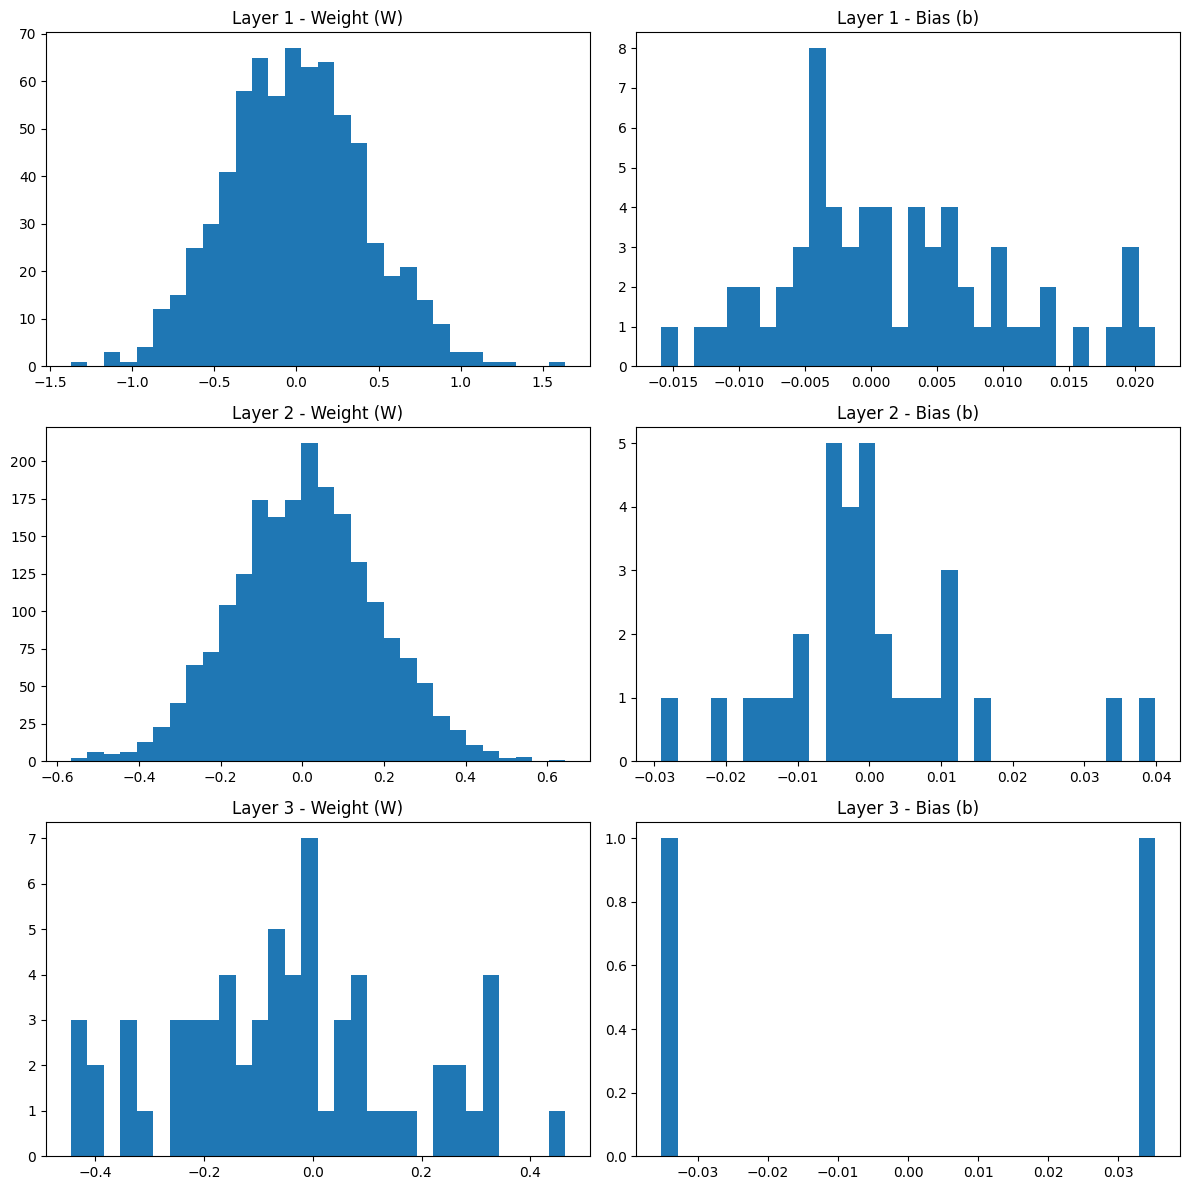


               DISTRIBUSI GRADIEN (ERROR SIGNAL)                 
Layer   | Param | Min        | Max        | Mean       | Std       
-----------------------------------------------------------------
1       | dW    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
        | db    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
-----------------------------------------------------------------
2       | dW    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
        | db    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
-----------------------------------------------------------------
3       | dW    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
        | db    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
-----------------------------------------------------------------


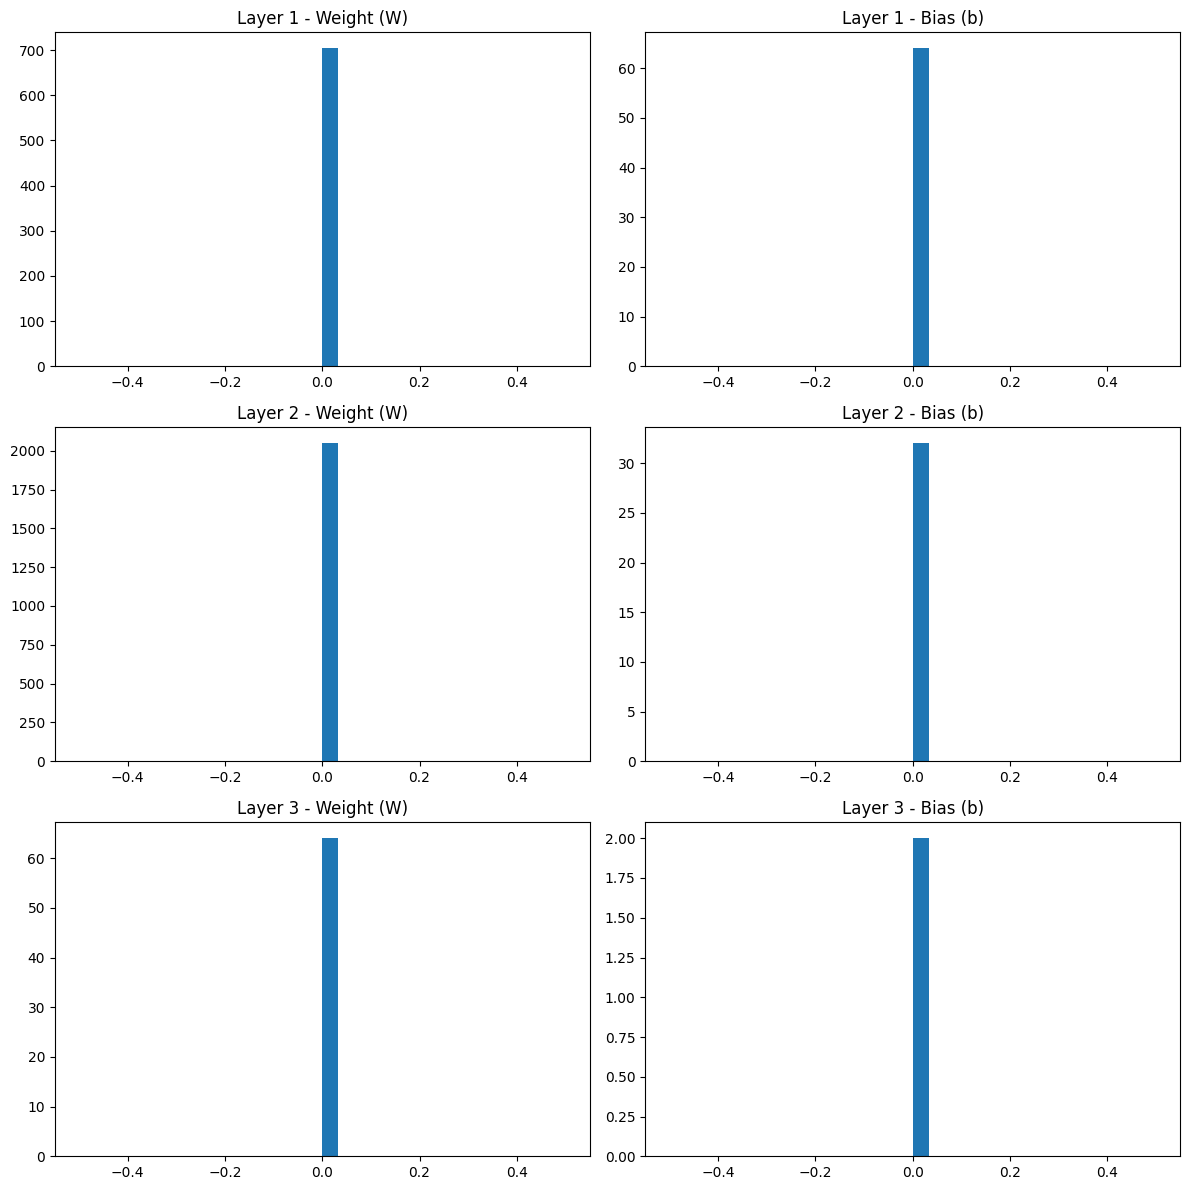

In [21]:
# Distribusi bobot dan gradien

for lr in learning_rates:
    print(f"\n{'='*50}\nLR = {lr}\n{'='*50}")
    results[lr]['model'].display_weight_distribution([1, 2, 3])
    results[lr]['model'].display_gradient_distribution([1, 2, 3])

LR=0.1 menghasilkan bobot dengan rentang dan std yang lebih besar (bobot tersebar lebih lebar), menunjukkan update yang agresif. LR=0.01 dan LR=0.001 menghasilkan distribusi bobot yang lebih terpusat di sekitar nol. Dari sisi gradien, LR=0.1 menunjukkan gradien yang lebih besar di layer awal, sementara LR=0.001 memiliki gradien yang sangat kecil.

#### Kesimpulan

LR=0.01 adalah pilihan optimal untuk dataset ini, karena seperti yang dapat dilihat pada pengujian di atas, LR ini menghasilkan akurasi tertinggi (75.20%) dengan kurva loss yang stabil dan tidak overfit. LR=0.1 meskipun training loss nya rendah, terbukti overfit dilihat dari validation loss yang naik. LR=0.001 belum konvergen dalam 100 epoch sehingga membutuhkan lebih banyak iterasi untuk mencapai performa optimal.

### 2. Pengaruh Regularisasi

Eksperimen dengan 3 kondisi: tanpa regularisasi, L1, dan L2.

In [22]:
LAYER_SIZES = [X_train.shape[1], 64, 32, 2]
ACTIVATIONS = ["relu", "relu", "softmax"]
EPOCHS = 100
BATCH_SIZE = 32
SEED = 42

regularizations = {
    "No Reg":   {"l1_lambda": 0.0,    "l2_lambda": 0.0},
    "L1":       {"l1_lambda": 0.0001, "l2_lambda": 0.0},
    "L2":       {"l1_lambda": 0.0,    "l2_lambda": 0.0001},
}

histories_reg = {}
results_reg = {}

for name, reg_params in regularizations.items():
    print(f"\n{'='*50}\nTraining dengan {name}\n{'='*50}")
    model = FFNN(
        layer_sizes=LAYER_SIZES,
        activations=ACTIVATIONS,
        init_method="he",
        learning_rate=0.001,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        seed=SEED,
        verbose=1,
        **reg_params
    )
    history = model.fit(X_train, y_train_onehot, X_val=X_val, y_val=y_val_onehot)
    histories_reg[name] = history
    results_reg[name] = {
        "model": model,
        "accuracy": accuracy_score(y_test.ravel(), np.argmax(model.predict(X_test), axis=1))
    }


Training dengan No Reg
Epoch   1/100 [>....................] - loss: 0.9649 - acc: 0.4869 - val_loss: 0.7726 - val_acc: 0.5425
Epoch   2/100 [>....................] - loss: 0.7098 - acc: 0.6038 - val_loss: 0.6499 - val_acc: 0.6312
Epoch   3/100 [>....................] - loss: 0.6462 - acc: 0.6556 - val_loss: 0.6225 - val_acc: 0.6687
Epoch   4/100 [>....................] - loss: 0.6278 - acc: 0.6715 - val_loss: 0.6081 - val_acc: 0.6787
Epoch   5/100 [=>...................] - loss: 0.6160 - acc: 0.6811 - val_loss: 0.5962 - val_acc: 0.6887
Epoch   6/100 [=>...................] - loss: 0.6068 - acc: 0.6872 - val_loss: 0.5855 - val_acc: 0.6963
Epoch   7/100 [=>...................] - loss: 0.5987 - acc: 0.6929 - val_loss: 0.5763 - val_acc: 0.7050
Epoch   8/100 [=>...................] - loss: 0.5918 - acc: 0.6992 - val_loss: 0.5686 - val_acc: 0.7100
Epoch   9/100 [=>...................] - loss: 0.5860 - acc: 0.7033 - val_loss: 0.5618 - val_acc: 0.7100
Epoch  10/100 [==>..................] - 

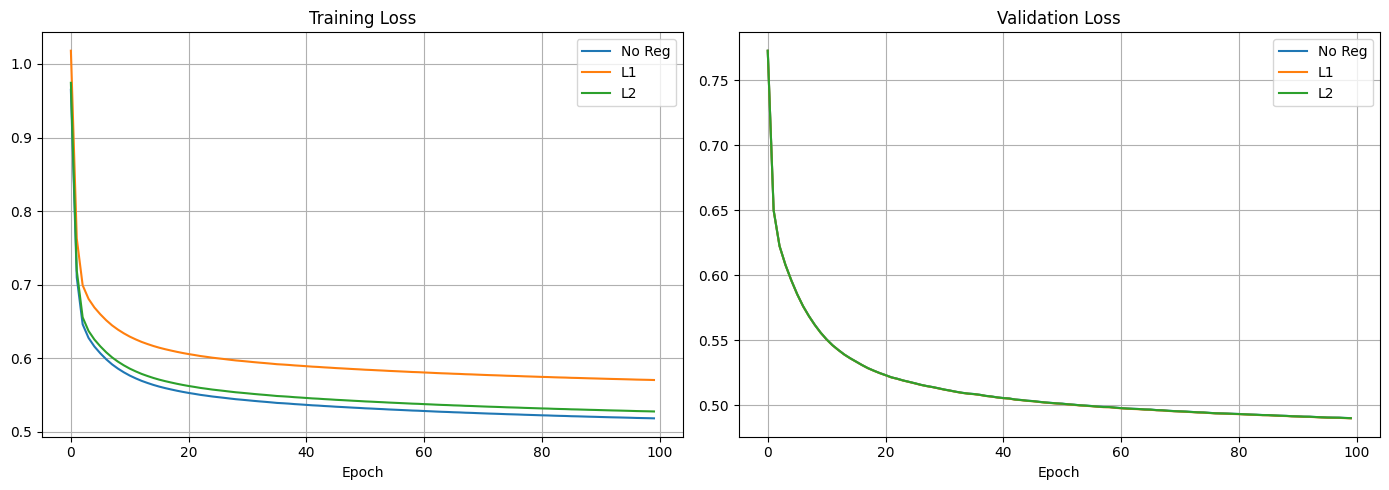

In [23]:
# Perbandingan training & validation loss

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name in regularizations:
    axes[0].plot(histories_reg[name]['train_loss'], label=name)
    axes[1].plot(histories_reg[name]['val_loss'],   label=name)

axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True)
axes[1].set_title('Validation Loss'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.show()

No Reg dan L2 menunjukkan kurva training loss yang hampir identik dan berhimpit, keduanya konvergen ke sekitar ~0.52. L1 konvergen lebih lambat dan berhenti di training loss yang lebih tinggi (~0.58), karena penalti L1 yang mendorong sparsity membuat optimisasi lebih sulit. Pada validation loss, ketiga model juga hampir berhimpit dan konvergen ke nilai yang sama (~0.49), menunjukkan bahwa regularisasi dengan lambda=0.0001 tidak memberikan dampak signifikan terhadap generalisasi model pada dataset ini.

In [24]:
# Perbandingan akurasi akhir

for name in regularizations:
    print(f"{name:<10} | Test Accuracy: {results_reg[name]['accuracy']:.4f}")

No Reg     | Test Accuracy: 0.7455
L1         | Test Accuracy: 0.7440
L2         | Test Accuracy: 0.7455


Ketiga model menghasilkan akurasi yang hampir identik. Hal ini wajar karena nilai lambda yang digunakan (0.0001) sangat kecil sehingga pengaruh regularisasi terhadap bobot minimal. L2 menyamai No Regularisasi, sementara L1 sedikit lebih rendah kemungkinan karena penalti L1 mendorong sparsity yang sedikit mengurangi kapasitas model.


No Reg

               DISTRIBUSI BOBOT (WEIGHTS) & BIAS                 
Layer   | Param | Min        | Max        | Mean       | Std       
-----------------------------------------------------------------
1       | W     | -1.3731    | 1.6344     | -0.0045    | 0.4193    
        | b     | -0.0159    | 0.0215     | 0.0017     | 0.0086    
-----------------------------------------------------------------
2       | W     | -0.5667    | 0.6435     | 0.0071     | 0.1745    
        | b     | -0.0291    | 0.0399     | -0.0000    | 0.0135    
-----------------------------------------------------------------
3       | W     | -0.4448    | 0.4638     | -0.0478    | 0.2102    
        | b     | -0.0353    | 0.0353     | -0.0000    | 0.0353    
-----------------------------------------------------------------


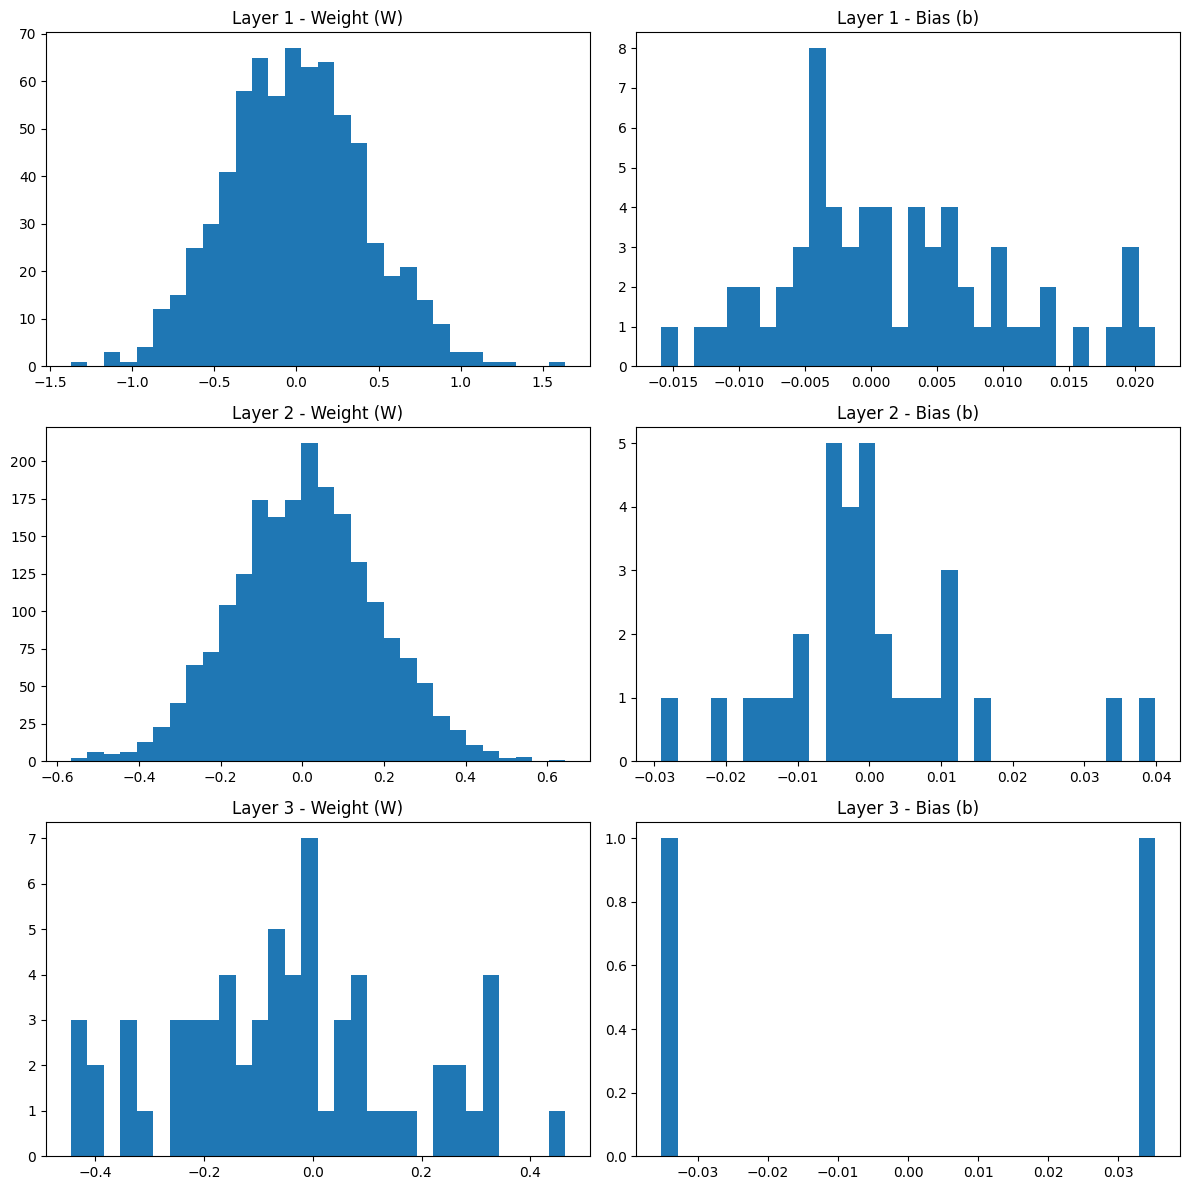


               DISTRIBUSI GRADIEN (ERROR SIGNAL)                 
Layer   | Param | Min        | Max        | Mean       | Std       
-----------------------------------------------------------------
1       | dW    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
        | db    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
-----------------------------------------------------------------
2       | dW    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
        | db    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
-----------------------------------------------------------------
3       | dW    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
        | db    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
-----------------------------------------------------------------


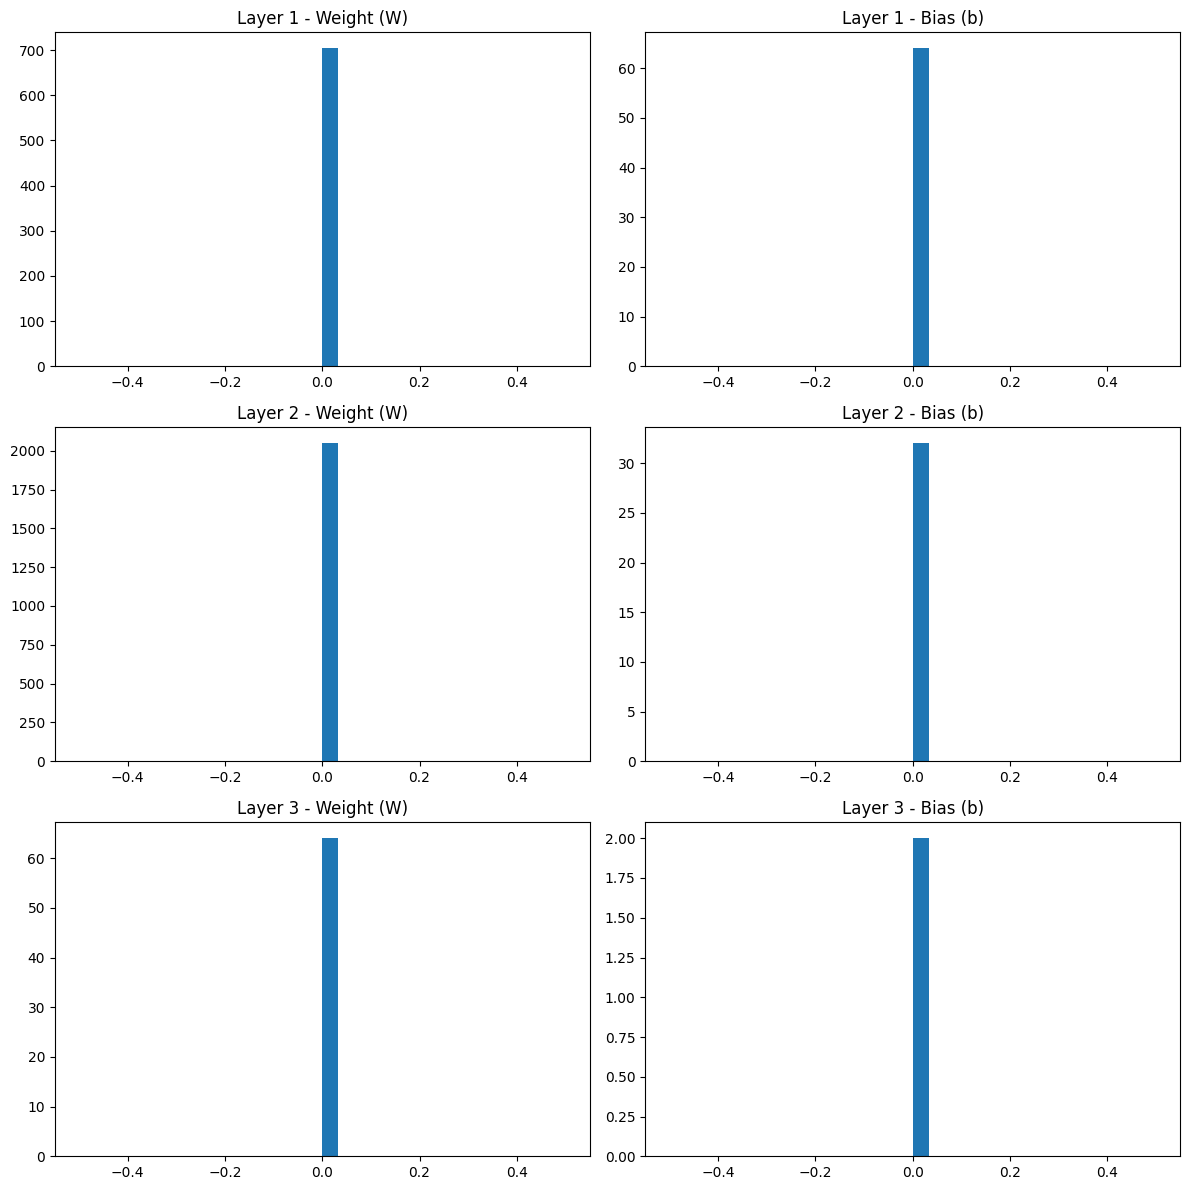


L1

               DISTRIBUSI BOBOT (WEIGHTS) & BIAS                 
Layer   | Param | Min        | Max        | Mean       | Std       
-----------------------------------------------------------------
1       | W     | -1.3707    | 1.6321     | -0.0045    | 0.4176    
        | b     | -0.0155    | 0.0216     | 0.0018     | 0.0086    
-----------------------------------------------------------------
2       | W     | -0.5645    | 0.6412     | 0.0071     | 0.1728    
        | b     | -0.0289    | 0.0400     | 0.0000     | 0.0135    
-----------------------------------------------------------------
3       | W     | -0.4434    | 0.4626     | -0.0474    | 0.2089    
        | b     | -0.0355    | 0.0355     | -0.0000    | 0.0355    
-----------------------------------------------------------------


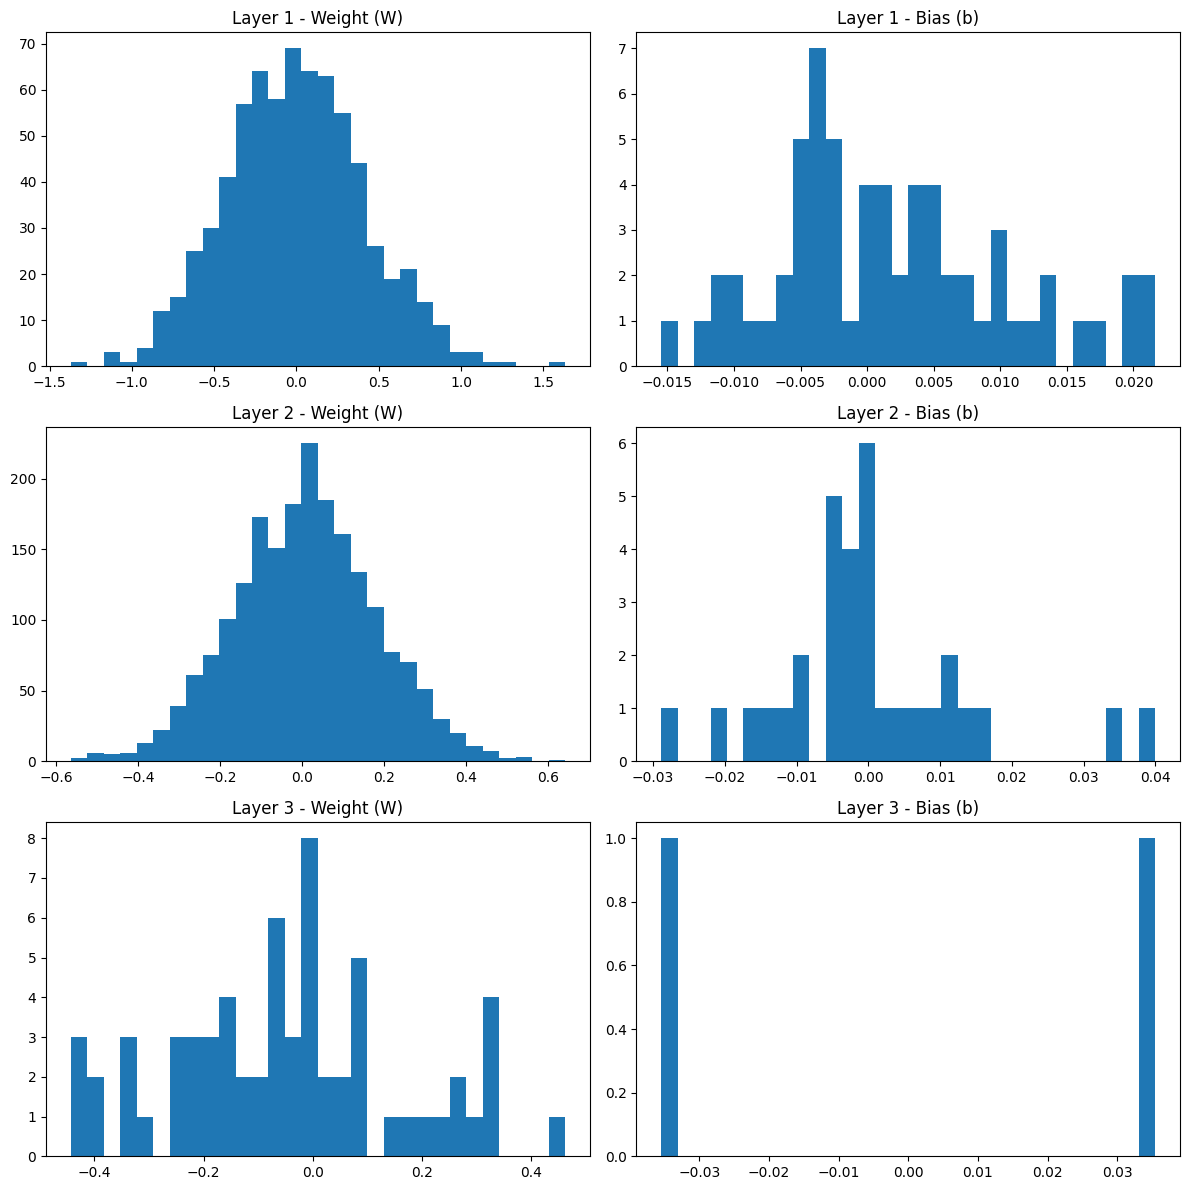


               DISTRIBUSI GRADIEN (ERROR SIGNAL)                 
Layer   | Param | Min        | Max        | Mean       | Std       
-----------------------------------------------------------------
1       | dW    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
        | db    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
-----------------------------------------------------------------
2       | dW    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
        | db    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
-----------------------------------------------------------------
3       | dW    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
        | db    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
-----------------------------------------------------------------


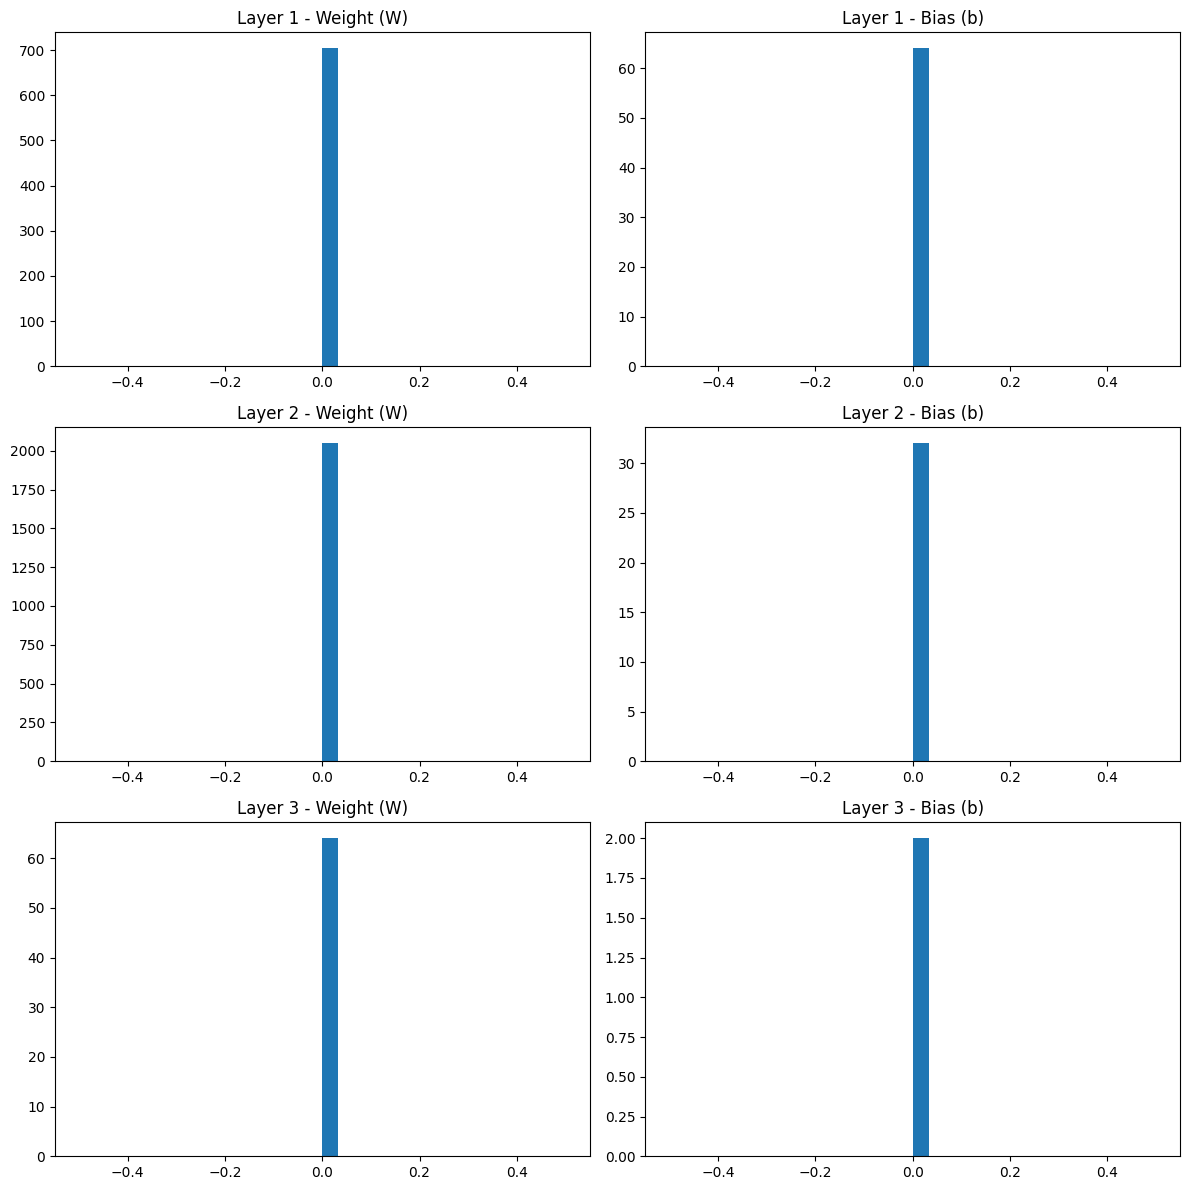


L2

               DISTRIBUSI BOBOT (WEIGHTS) & BIAS                 
Layer   | Param | Min        | Max        | Mean       | Std       
-----------------------------------------------------------------
1       | W     | -1.3700    | 1.6307     | -0.0045    | 0.4184    
        | b     | -0.0159    | 0.0216     | 0.0017     | 0.0086    
-----------------------------------------------------------------
2       | W     | -0.5654    | 0.6421     | 0.0071     | 0.1741    
        | b     | -0.0290    | 0.0400     | -0.0000    | 0.0135    
-----------------------------------------------------------------
3       | W     | -0.4439    | 0.4632     | -0.0477    | 0.2098    
        | b     | -0.0353    | 0.0353     | -0.0000    | 0.0353    
-----------------------------------------------------------------


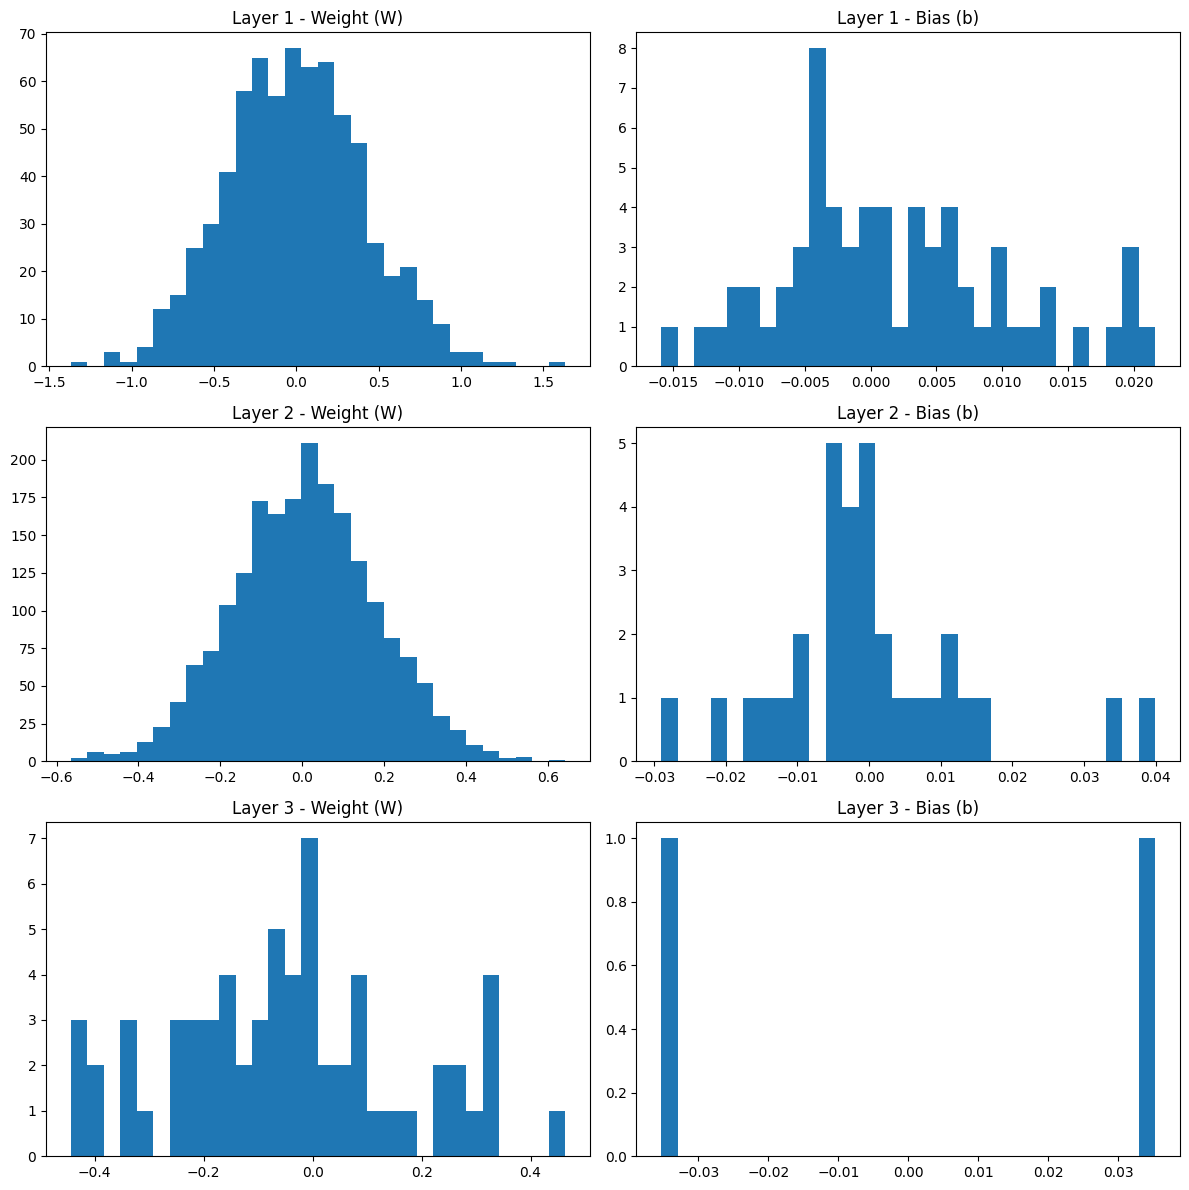


               DISTRIBUSI GRADIEN (ERROR SIGNAL)                 
Layer   | Param | Min        | Max        | Mean       | Std       
-----------------------------------------------------------------
1       | dW    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
        | db    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
-----------------------------------------------------------------
2       | dW    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
        | db    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
-----------------------------------------------------------------
3       | dW    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
        | db    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
-----------------------------------------------------------------


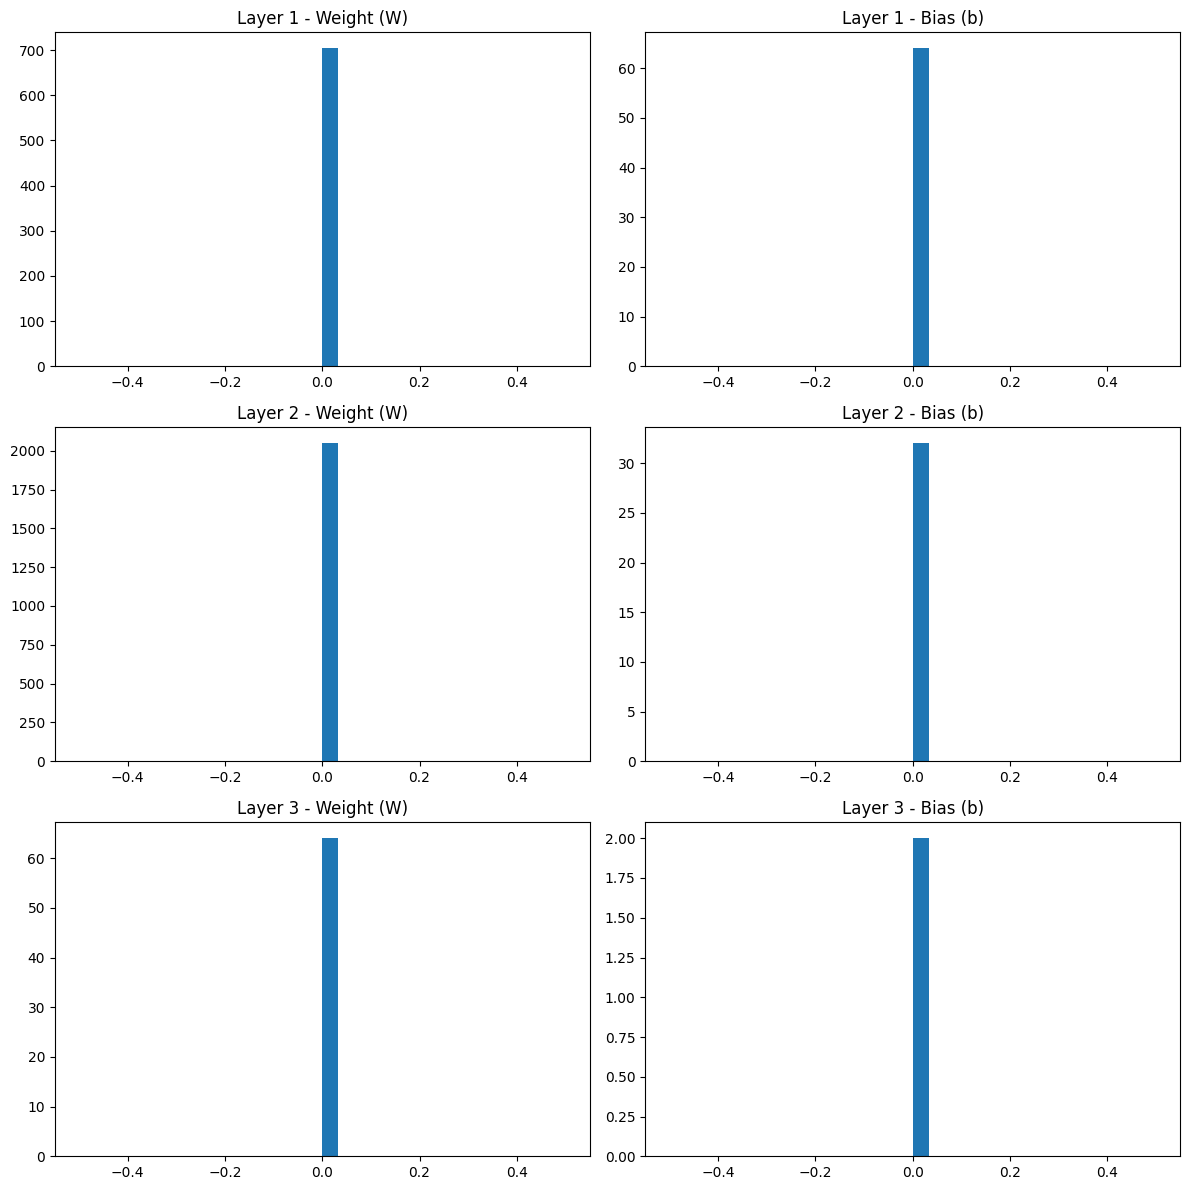

In [25]:
# dist bobot and bias

for name in regularizations:
    print(f"\n{'='*50}\n{name}\n{'='*50}")
    results_reg[name]['model'].display_weight_distribution([1, 2, 3])
    results_reg[name]['model'].display_gradient_distribution([1, 2, 3])

Model dengan L1 cenderung menghasilkan bobot yang lebih sparse (banyak nilai mendekati nol) karena sifat penalti L1 yang mendorong sparsity. L2 menghasilkan bobot dengan magnitude yang sedikit lebih kecil secara keseluruhan (weight decay) dibanding No Reg, namun distribusinya tetap smooth. Gradien pada L1 dan L2 sedikit lebih besar dibanding No Reg karena ada tambahan gradient dari penalty term.

**Kesimpulan**

Pada dataset ini dengan lambda=0.0001, regularisasi L1 dan L2 tidak memberikan perbedaan signifikan terhadap akurasi akhir maupun kurva loss. Ini mengindikasikan model tidak mengalami overfitting yang berarti pada konfigurasi yang digunakan, sehingga regularisasi tidak terlalu diperlukan.

### 3. Uji Perbandingan dengan Library sklearn MLP

In [26]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Buat model sklearn MLP
sklearn_model = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation='relu',
    solver='adam',
    learning_rate_init=0.01,
    max_iter=100,
    batch_size=32,
    random_state=42,
    verbose=1
)

# Training
print("Training sklearn MLPClassifier...")
sklearn_model.fit(X_train, y_train.ravel())

# Prediksi
y_pred_sklearn = sklearn_model.predict(X_test)

# Comparison Report
print("\n" + "="*60)
print("PERBANDINGAN MODEL")
print("="*60)

# Custom FFNN accuracy
y_pred_custom_labels = np.argmax(y_pred_probs, axis=1)
accuracy_custom = np.mean(y_pred_custom_labels == y_test.ravel())
print(f"\nCustom FFNN Accuracy: {accuracy_custom:.4f}")

# sklearn accuracy
accuracy_sklearn = accuracy_score(y_test.ravel(), y_pred_sklearn)
print(f"sklearn MLPClassifier Accuracy: {accuracy_sklearn:.4f}")

print("\n" + "="*60)
print("SKLEARN MODEL - CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test.ravel(), y_pred_sklearn))

print("\n" + "="*60)
print("CONFUSION MATRIX - SKLEARN")
print("="*60)
print(confusion_matrix(y_test.ravel(), y_pred_sklearn))

Training sklearn MLPClassifier...
Iteration 1, loss = 0.52733291
Iteration 2, loss = 0.50815729
Iteration 3, loss = 0.50185189
Iteration 4, loss = 0.49719774
Iteration 5, loss = 0.49573295
Iteration 6, loss = 0.49534482
Iteration 7, loss = 0.49410379
Iteration 8, loss = 0.49167162
Iteration 9, loss = 0.49019083
Iteration 10, loss = 0.48828760
Iteration 11, loss = 0.48627589
Iteration 12, loss = 0.48535497
Iteration 13, loss = 0.48475245
Iteration 14, loss = 0.48304471
Iteration 15, loss = 0.48034722
Iteration 16, loss = 0.47740176
Iteration 17, loss = 0.47805309
Iteration 18, loss = 0.47714138
Iteration 19, loss = 0.47598328
Iteration 20, loss = 0.47339357
Iteration 21, loss = 0.47239506
Iteration 22, loss = 0.47161022
Iteration 23, loss = 0.47180982
Iteration 24, loss = 0.46606290
Iteration 25, loss = 0.46755497
Iteration 26, loss = 0.46489257
Iteration 27, loss = 0.46547312
Iteration 28, loss = 0.46383830
Iteration 29, loss = 0.46281886
Iteration 30, loss = 0.46057445
Iteration 31, l

c:\Users\Syifa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


In [27]:
from ffnn.optimizer import AdamOptimizer
print(AdamOptimizer)  # pastikan ini class, bukan None
adam = AdamOptimizer()
print(adam.update)    # pastikan ini bound method

<class 'ffnn.optimizer.AdamOptimizer'>
<bound method AdamOptimizer.update of <ffnn.optimizer.AdamOptimizer object at 0x00000169E56C5A90>>


Epoch   1/100 [>....................] - loss: 0.5788 - acc: 0.7165 - val_loss: 0.4889 - val_acc: 0.7600
Epoch   2/100 [>....................] - loss: 0.5201 - acc: 0.7458 - val_loss: 0.4790 - val_acc: 0.7688
Epoch   3/100 [>....................] - loss: 0.5091 - acc: 0.7517 - val_loss: 0.4771 - val_acc: 0.7725
Epoch   4/100 [>....................] - loss: 0.5006 - acc: 0.7536 - val_loss: 0.4761 - val_acc: 0.7738
Epoch   5/100 [=>...................] - loss: 0.4959 - acc: 0.7583 - val_loss: 0.4799 - val_acc: 0.7638
Epoch   6/100 [=>...................] - loss: 0.4927 - acc: 0.7599 - val_loss: 0.4718 - val_acc: 0.7688
Epoch   7/100 [=>...................] - loss: 0.4904 - acc: 0.7628 - val_loss: 0.4706 - val_acc: 0.7762
Epoch   8/100 [=>...................] - loss: 0.4883 - acc: 0.7660 - val_loss: 0.4740 - val_acc: 0.7775
Epoch   9/100 [=>...................] - loss: 0.4837 - acc: 0.7665 - val_loss: 0.4781 - val_acc: 0.7650
Epoch  10/100 [==>..................] - loss: 0.4816 - acc: 0.76

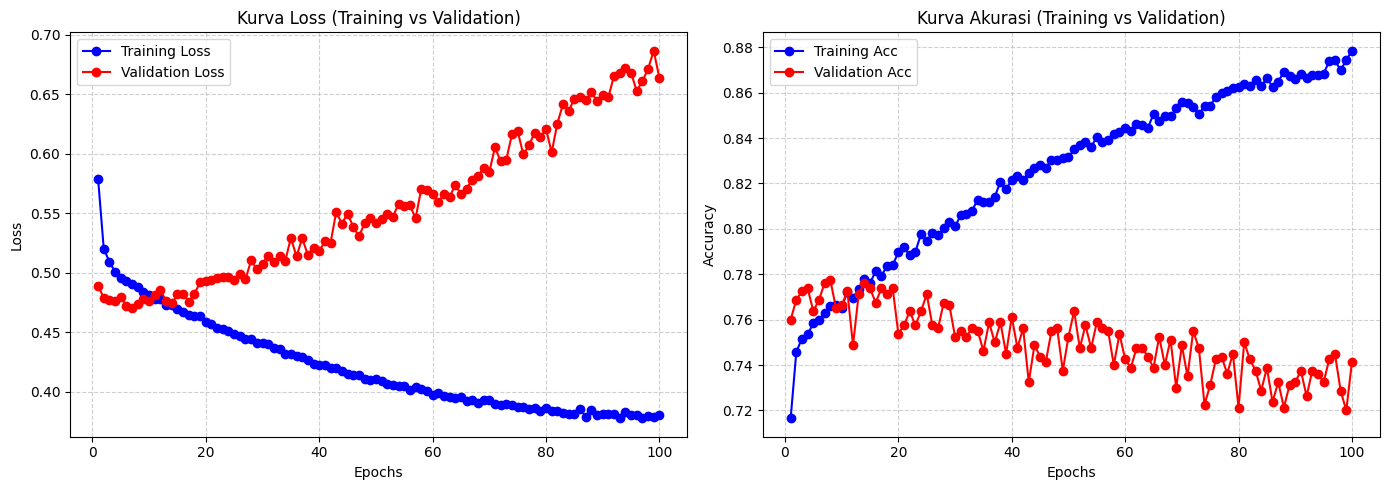


Custom FFNN Accuracy: 0.7135


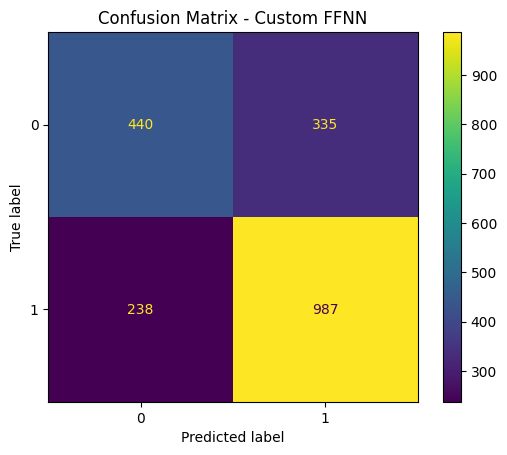

In [28]:
from ffnn.ffnn import FFNN
from ffnn import utils
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Shared hyperparams
HIDDEN_LAYERS = (64, 32)
LR = 0.001
EPOCHS = 100
BATCH_SIZE = 32
SEED = 42

y_train_onehot = utils.create_one_hot(y_train.ravel(), num_classes=2)
y_val_onehot   = utils.create_one_hot(y_val.ravel(), num_classes=2)
y_test_onehot  = utils.create_one_hot(y_test.ravel(), num_classes=2)

model = FFNN(
    layer_sizes=[X_train.shape[1], *HIDDEN_LAYERS, 2],
    activations=["relu", "relu", "softmax"],
    init_method="he",
    learning_rate=LR,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    seed=SEED,
    verbose=1,
    optimizer="adam"
)

history = model.fit(X_train, y_train_onehot, X_val=X_val, y_val=y_val_onehot)
utils.plot_history(history)

y_pred = np.argmax(model.predict(X_test), axis=1)
print(f"\nCustom FFNN Accuracy: {accuracy_score(y_test.ravel(), y_pred):.4f}")

cm = confusion_matrix(y_test.ravel(), y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix - Custom FFNN")
plt.show()


Sklearn MLP Accuracy: 0.7115


c:\Users\Syifa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


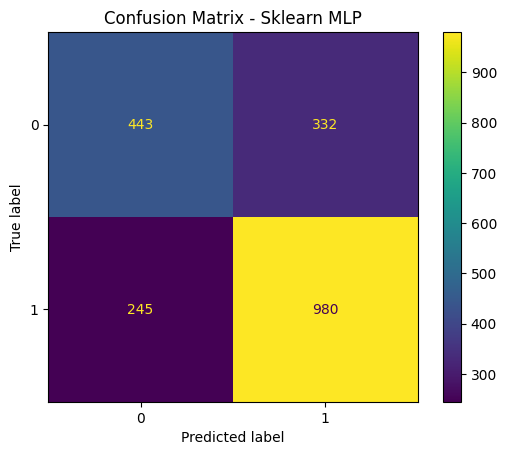

In [29]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

sklearn_model = MLPClassifier(
    hidden_layer_sizes=HIDDEN_LAYERS,   # same (64, 32)
    activation="relu",                  # same
    solver="adam",                       # same as custom (vanilla GD)
    learning_rate_init=LR,              # same 0.001
    max_iter=EPOCHS,                    # same 100
    batch_size=BATCH_SIZE,              # same 32
    random_state=SEED,                  # same 42
    verbose=0,
)

sklearn_model.fit(X_train, y_train.ravel())

y_pred_sk = sklearn_model.predict(X_test)
print(f"\nSklearn MLP Accuracy: {accuracy_score(y_test.ravel(), y_pred_sk):.4f}")

cm_sk = confusion_matrix(y_test.ravel(), y_pred_sk)
ConfusionMatrixDisplay(cm_sk).plot()
plt.title("Confusion Matrix - Sklearn MLP")
plt.show()